# Установка и импорт библиотек

In [ ]:
import re
import math
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from collections import Counter, defaultdict

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelEncoder

import time
from tqdm import tqdm
from multiprocessing import Pool, cpu_count

import torch
import torch as th
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
!pip install torch-geometric -q
!pip install transformers -q
!pip install optuna -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 15.6 MB/s eta 0:00:00


In [ ]:
import networkx as nx

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torch_geometric.nn import GATConv
from torch_geometric.nn import SAGEConv
from torch_geometric.utils import negative_sampling

from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

import optuna
from optuna.trial import Trial
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. Загрузка данных

In [ ]:
import kagglehub

path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'amazon-fine-food-reviews' dataset.
Path to dataset files: /kaggle/input/amazon-fine-food-reviews


In [ ]:
# Загрузка всего датасета
df = pd.read_csv(f"{path}/Reviews.csv")
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [ ]:
df.shape

(568454, 10)

In [ ]:
# Оставляю только важные для работы колонки
df = df[['UserId', 'ProductId', 'Text', 'Summary', 'Score']]
df.head()

,UserId,ProductId,Text,Summary,Score
0,A3SGXH7AUHU8GW,B001E4KFG0,I have bought several of the Vitality canned d...,Good Quality Dog Food,5
1,A1D87F6ZCVE5NK,B00813GRG4,Product arrived labeled as Jumbo Salted Peanut...,Not as Advertised,1
2,ABXLMWJIXXAIN,B000LQOCH0,This is a confection that has been around a fe...,"""Delight"" says it all",4
3,A395BORC6FGVXV,B000UA0QIQ,If you are looking for the secret ingredient i...,Cough Medicine,2
4,A1UQRSCLF8GW1T,B006K2ZZ7K,Great taffy at a great price. There was a wid...,Great taffy,5


# 2. EDA и предобработка датасета

## Первичный описательный анализ основных характеристик датасета

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   UserId     568454 non-null  object
 1   ProductId  568454 non-null  object
 2   Text       568454 non-null  object
 3   Summary    568427 non-null  object
 4   Score      568454 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 21.7+ MB


In [ ]:
# Описание категориальных признаков
df.describe(include="O")

,UserId,ProductId,Text,Summary
count,568454,568454,568454,568427
unique,256059,74258,393579,295742
top,A3OXHLG6DIBRW8,B007JFMH8M,"This review will make me sound really stupid, ...",Delicious!
freq,448,913,199,2462


In [ ]:
# Основные характеристики признака Score - оценки
df.describe()

,Score
count,568454.000000
mean,4.183199
std,1.310436
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


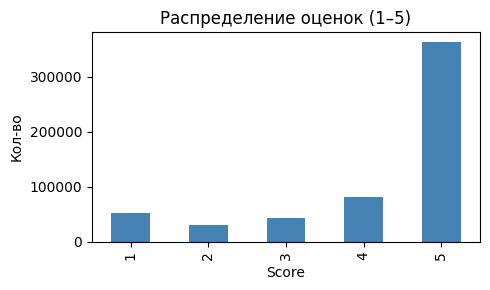

In [ ]:
plt.figure(figsize=(5,3))
df['Score'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Распределение оценок (1–5)')
plt.xlabel('Score')
plt.ylabel('Кол-во')
plt.tight_layout()
plt.show()

## Анализ пропусков и дубликатов, предобработка датасета

In [ ]:
print("Дубликатов по тексту:", df.duplicated(subset=['UserId', 'ProductId', 'Text']).sum())

Дубликатов по тексту: 1309


In [ ]:
# Удаление дубликатов
df = df.drop_duplicates(subset=['UserId', 'ProductId', 'Text'], keep='first')
df.shape

(567145, 5)

In [ ]:
print("Пропуски:")
df.isnull().sum()

Пропуски:


,0
UserId,0
ProductId,0
Text,0
Summary,27
Score,0


**Вывод:** в значимых для анализа колонках пропуски отсутствуют (столбец Summary был оставлен на всякий случай, при обучении моделей не использовался, поэтому пропуски в нём не в счёт).

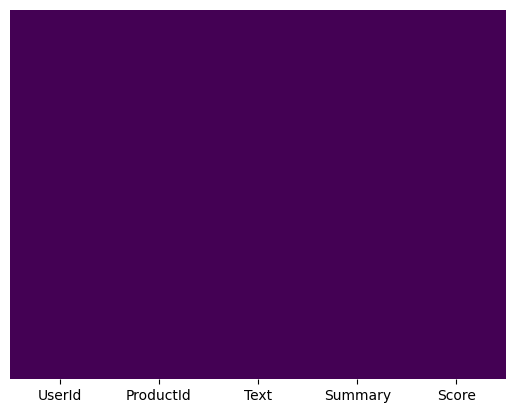

In [ ]:
sns.heatmap(df.isna(), cmap='viridis', cbar=False, yticklabels=False)
plt.show()

In [ ]:
# Бинаризация - добавление нового признака Sentiment на основе оценки

df_bin = df[df['Score'] != 3].copy()
df_bin['Sentiment'] = (df_bin['Score'] >= 4).astype(int) # 1 = pos, 0 = neg
print("Размер df_bin:", len(df_bin))
df_bin.head()

Размер df_bin: 524587


,UserId,ProductId,Text,Summary,Score,Sentiment
0,A3SGXH7AUHU8GW,B001E4KFG0,I have bought several of the Vitality canned d...,Good Quality Dog Food,5,1
1,A1D87F6ZCVE5NK,B00813GRG4,Product arrived labeled as Jumbo Salted Peanut...,Not as Advertised,1,0
2,ABXLMWJIXXAIN,B000LQOCH0,This is a confection that has been around a fe...,"""Delight"" says it all",4,1
3,A395BORC6FGVXV,B000UA0QIQ,If you are looking for the secret ingredient i...,Cough Medicine,2,0
4,A1UQRSCLF8GW1T,B006K2ZZ7K,Great taffy at a great price. There was a wid...,Great taffy,5,1


In [ ]:
# Проверка дисбаланса классов
counts = df_bin['Sentiment'].value_counts()
print("Классы:")
counts

Классы:


,count
Sentiment,
1,442869
0,81718


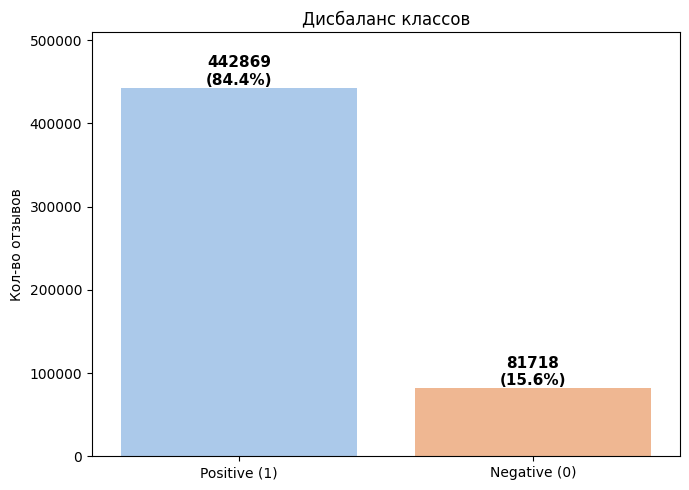

In [ ]:
plt.figure(figsize=(7, 5))
total = len(df_bin)
ax = sns.barplot(
    x=['Positive (1)', 'Negative (0)'],
    y=counts.values,
    hue=['Positive (1)', 'Negative (0)'],
    palette='pastel',
    legend=False
)

for i, p in enumerate(ax.patches):
    count = counts.values[i]
    percentage = f'{100 * count / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(f'{count}\n({percentage})', (x, y),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Дисбаланс классов')
plt.ylabel('Кол-во отзывов')
plt.ylim(0, max(counts.values) * 1.15)
plt.tight_layout()
plt.show()

In [ ]:
df_bin['text_len'] = df_bin['clean_text'].str.split().str.len()
df_bin['text_len'].describe()

,text_len
count,524587.000000
mean,38.270674
std,38.232526
min,0.000000
25%,16.000000
50%,27.000000
75%,46.000000
max,1519.000000


In [ ]:
df_bin['text_len'] = df_bin['light_text'].str.split().str.len()
df_bin['text_len'].describe()

,text_len
count,524587.000000
mean,79.209973
std,76.834544
min,0.000000
25%,33.000000
50%,56.000000
75%,97.000000
max,2486.000000


In [ ]:
df_bin['text_len'] = df_bin['Text'].str.split().str.len()
df_bin['text_len'].describe()

,text_len
count,524587.000000
mean,78.587376
std,76.908797
min,3.000000
25%,33.000000
50%,55.000000
75%,96.000000
max,2520.000000


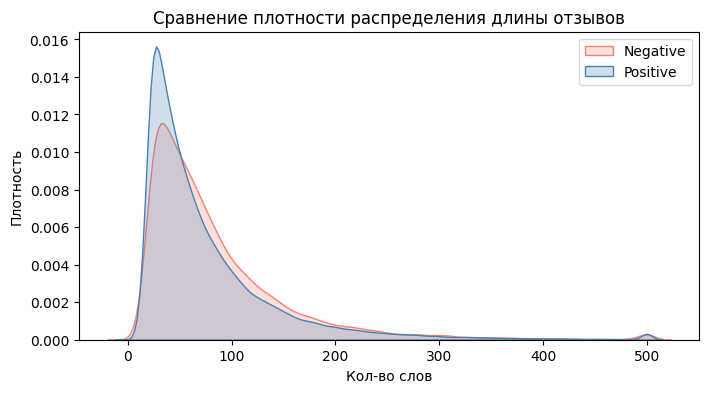

In [ ]:
plt.figure(figsize=(8, 4))
sns.kdeplot(df_bin[df_bin['Sentiment'] == 0]['text_len'].clip(upper=500),
            label='Negative', fill=True, color='salmon')
sns.kdeplot(df_bin[df_bin['Sentiment'] == 1]['text_len'].clip(upper=500),
            label='Positive', fill=True, color='steelblue')

plt.title('Сравнение плотности распределения длины отзывов')
plt.xlabel('Кол-во слов')
plt.ylabel('Плотность')
plt.legend()
plt.show()

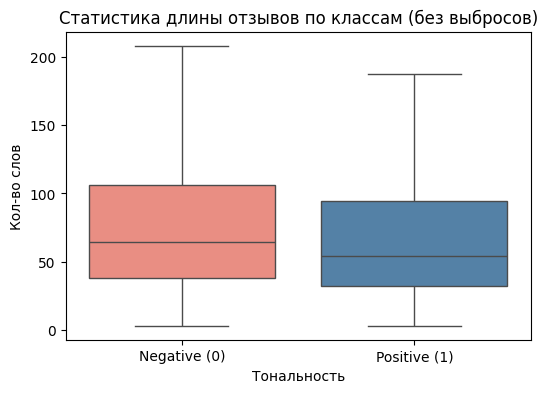

In [ ]:
plt.figure(figsize=(6, 4))
palette_colors = {0: 'salmon', 1: 'steelblue'}

sns.boxplot(
    x='Sentiment',
    y='text_len',
    data=df_bin,
    hue='Sentiment',
    palette=palette_colors,
    showfliers=False,
    legend=False
)

plt.title('Статистика длины отзывов по классам (без выбросов)')
plt.xticks([0, 1], ['Negative (0)', 'Positive (1)'])
plt.ylabel('Кол-во слов')
plt.xlabel('Тональность')
plt.show()

In [ ]:
print("Статистика длины текста:")
df_bin.groupby('Sentiment')['text_len'].describe().round(1)

Статистика длины текста:


,count,mean,std,min,25%,50%,75%,max
Sentiment,,,,,,,,
0,81718.0,86.6,82.1,3.0,38.0,64.0,106.0,2149.0
1,442869.0,77.1,75.8,3.0,32.0,54.0,94.0,2520.0


In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

df_bin['clean_text'] = df_bin['Text'].apply(preprocess_text)
df_bin.head(3)

,UserId,ProductId,Text,Summary,Score,Sentiment,clean_text
0,A3SGXH7AUHU8GW,B001E4KFG0,I have bought several of the Vitality canned d...,Good Quality Dog Food,5,1,bought several vitality canned dog food produc...
1,A1D87F6ZCVE5NK,B00813GRG4,Product arrived labeled as Jumbo Salted Peanut...,Not as Advertised,1,0,product arrived labeled jumbo salted peanut pe...
2,ABXLMWJIXXAIN,B000LQOCH0,This is a confection that has been around a fe...,"""Delight"" says it all",4,1,confection around century light pillowy citrus...


In [ ]:
def preprocess_light(text):
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_bin['light_text'] = df_bin['Text'].apply(preprocess_light)
df_bin.head(3)

,UserId,ProductId,Text,Summary,Score,Sentiment,clean_text,light_text
0,A3SGXH7AUHU8GW,B001E4KFG0,I have bought several of the Vitality canned d...,Good Quality Dog Food,5,1,bought several vitality canned dog food produc...,i have bought several of the vitality canned d...
1,A1D87F6ZCVE5NK,B00813GRG4,Product arrived labeled as Jumbo Salted Peanut...,Not as Advertised,1,0,product arrived labeled jumbo salted peanut pe...,product arrived labeled as jumbo salted peanut...
2,ABXLMWJIXXAIN,B000LQOCH0,This is a confection that has been around a fe...,"""Delight"" says it all",4,1,confection around century light pillowy citrus...,this is a confection that has been around a fe...


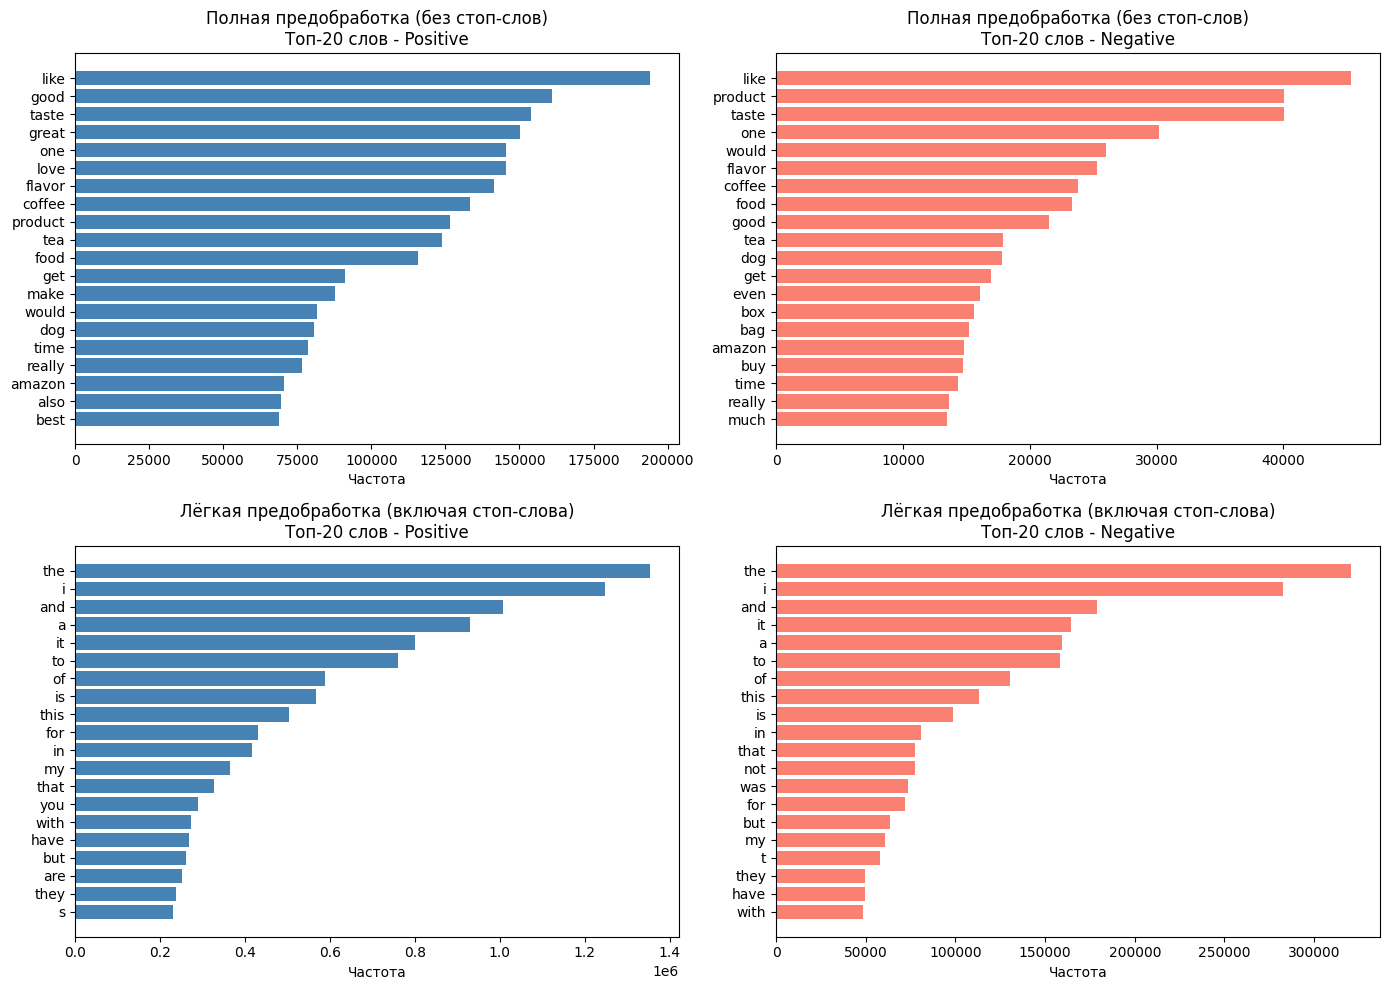

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, (text_col, label) in enumerate([
    ('clean_text', 'Полная предобработка (без стоп-слов)'),
    ('light_text', 'Лёгкая предобработка (включая стоп-слова)')]):
    for col, (sentiment, title, color) in enumerate([
        (1, 'Positive', 'steelblue'),
        (0, 'Negative', 'salmon')]):
        texts = ' '.join(df_bin[df_bin['Sentiment'] == sentiment][text_col])
        words, counts = zip(*Counter(texts.split()).most_common(20))

        ax = axes[row][col]
        ax.barh(words[::-1], counts[::-1], color=color)
        ax.set_title(f'{label}\nТоп-20 слов - {title}')
        ax.set_xlabel('Частота')

plt.tight_layout()
plt.show()

In [ ]:
df_bin.to_csv('df_bin.csv', index=False)
print("Сохранено")

Сохранено


## Разделение на трейновую, валидационную и тестовую выборки

In [ ]:
# Стратификация, чтобы сохранить баланс классов в каждой выборке
train_df, temp_df = train_test_split(
    df_bin, test_size=0.3, random_state=42, stratify=df_bin['Sentiment']
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df['Sentiment']
)

print(f"Train: {len(train_df)} ({len(train_df)/len(df_bin)*100:.1f}%)")
print(f"Val:   {len(val_df)} ({len(val_df)/len(df_bin)*100:.1f}%)")
print(f"Test:  {len(test_df)} ({len(test_df)/len(df_bin)*100:.1f}%)\n")

# Проверка баланса классов в каждой выборке
for name, subset in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    pos = subset['Sentiment'].mean()
    print(f"{name} - Positive: {pos:.2%}, Negative: {1-pos:.2%}")

Train: 367210 (70.0%)
Val:   78688 (15.0%)
Test:  78689 (15.0%)

Train - Positive: 84.42%, Negative: 15.58%
Val - Positive: 84.42%, Negative: 15.58%
Test - Positive: 84.42%, Negative: 15.58%


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Используем:", device)

Используем: cuda


## Создание подвыборки датасета с undersampling (12 тыс. строк)

In [ ]:
N_SUBSAMPLE = 6000  # на каждый класс

sub_pos = df_bin[df_bin['Sentiment']==1].sample(n=N_SUBSAMPLE, random_state=42)
sub_neg = df_bin[df_bin['Sentiment']==0].sample(n=N_SUBSAMPLE, random_state=42)
df_sub  = pd.concat([sub_pos, sub_neg]).sample(frac=1, random_state=42).reset_index(drop=True)

sub_train, sub_temp = train_test_split(df_sub, test_size=0.3,
                                        random_state=42,
                                        stratify=df_sub['Sentiment'])
sub_val, sub_test   = train_test_split(sub_temp, test_size=0.5,
                                        random_state=42,
                                        stratify=sub_temp['Sentiment'])

print(f"Sub train: {len(sub_train)}, val: {len(sub_val)}, test: {len(sub_test)}")
print(f"Баланс train: {sub_train['Sentiment'].value_counts().to_dict()}")

Sub train: 8400, val: 1800, test: 1800
Баланс train: {0: 4200, 1: 4200}


# 3. Реализация моделей

## 3.1 VADER

### На полном датасете

100%|██████████| 78689/78689 [01:04<00:00, 1211.76it/s]


              precision    recall  f1-score   support

    Negative       0.64      0.42      0.51     12258
    Positive       0.90      0.96      0.93     66431

    accuracy                           0.87     78689
   macro avg       0.77      0.69      0.72     78689
weighted avg       0.86      0.87      0.86     78689

ROC-AUC: 0.688


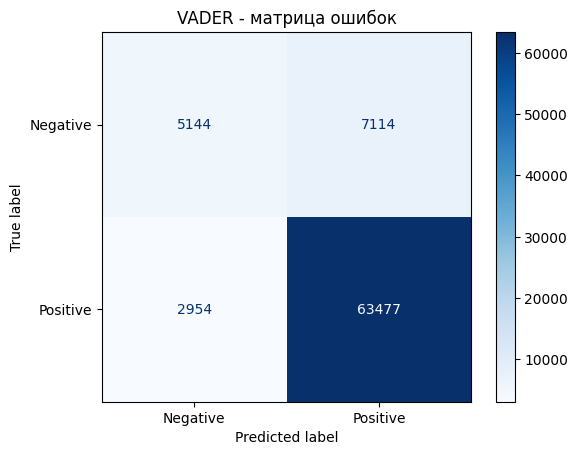

In [ ]:
tqdm.pandas()
start_time = time.time()

sia = SentimentIntensityAnalyzer()

def vader_predict(text):
    score = sia.polarity_scores(text)['compound']
    return 1 if score >= 0 else 0

test_df = test_df.copy()
test_df['vader_pred'] = test_df['Text'].progress_apply(vader_predict)
vader_time = time.time() - start_time

y_true = test_df['Sentiment']
y_pred = test_df['vader_pred']

vader_f1 = f1_score(y_true, y_pred, average='macro')
vader_auc = roc_auc_score(y_true, y_pred)

print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))
print("ROC-AUC:", roc_auc_score(y_true, y_pred).round(3))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')
plt.title('VADER - матрица ошибок')
plt.show()

In [ ]:
print("Время обучения:", vader_time)

Время обучения: 65.06874823570251


### На подвыборке

100%|██████████| 1800/1800 [00:02<00:00, 811.54it/s]


Результаты VADER на подвыборке (1800 строк):
Время выполнения: 2.22 сек.
F1-macro: 0.638
ROC-AUC: 0.668

               precision    recall  f1-score   support

    Negative       0.90      0.38      0.53       900
    Positive       0.61      0.96      0.74       900

    accuracy                           0.67      1800
   macro avg       0.75      0.67      0.64      1800
weighted avg       0.75      0.67      0.64      1800



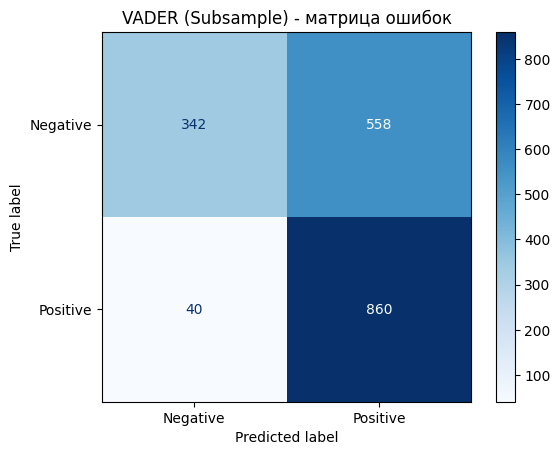

In [ ]:
tqdm.pandas()
sia = SentimentIntensityAnalyzer()

def vader_predict(text):
    score = sia.polarity_scores(text)['compound']
    return 1 if score >= 0 else 0

current_test = sub_test.copy()

start_time = time.time()
current_test['vader_pred'] = current_test['Text'].progress_apply(vader_predict)
vader_time_sub = time.time() - start_time # Время для таблицы подвыборки

y_true_sub = current_test['Sentiment']
y_pred_sub = current_test['vader_pred']

vader_f1_sub = f1_score(y_true_sub, y_pred_sub, average='macro')
vader_auc_sub = roc_auc_score(y_true_sub, y_pred_sub)

print(f"Результаты VADER на подвыборке ({len(current_test)} строк):")
print(f"Время выполнения: {vader_time_sub:.2f} сек.")
print(f"F1-macro: {vader_f1_sub:.3f}")
print(f"ROC-AUC: {vader_auc_sub:.3f}")
print("\n", classification_report(y_true_sub, y_pred_sub, target_names=['Negative', 'Positive']))

cm = confusion_matrix(y_true_sub, y_pred_sub)
disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')
plt.title('VADER (Subsample) - матрица ошибок')
plt.show()

## 3.2 TextRank + VADER

### На полном датасете

Запуск TextRank на 78689 текстов
Используется ядер: 2


Полный TextRank: 100%|██████████| 78689/78689 [02:43<00:00, 482.26it/s]



Время выполнения: 163.33 сек.
F1-macro: 0.608
ROC-AUC: 0.596

               precision    recall  f1-score   support

    Negative       0.40      0.27      0.32     12258
    Positive       0.87      0.93      0.90     66431

    accuracy                           0.82     78689
   macro avg       0.64      0.60      0.61     78689
weighted avg       0.80      0.82      0.81     78689



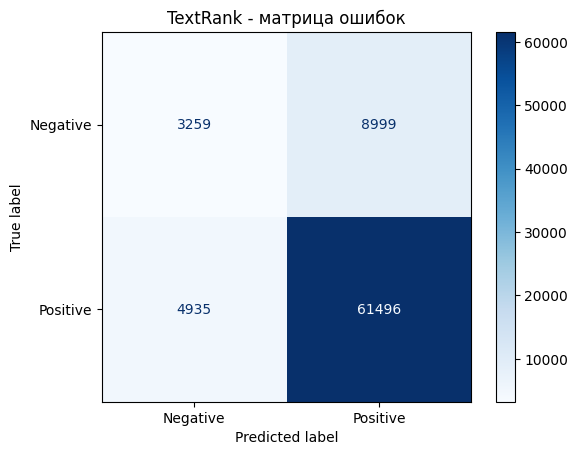

In [ ]:
sia_global = None

def init_worker():
    global sia_global
    sia_global = SentimentIntensityAnalyzer()

def textrank_sentiment_worker(text):
    # Если текст пустой или слишком короткий для графа
    if not isinstance(text, str) or len(text.split()) < 3:
        return 1

    tokens = text.split()
    window_size = 4
    cooc = defaultdict(lambda: defaultdict(int))

    # Построение графа совместной встречаемости
    for i, word in enumerate(tokens):
        for j in range(i + 1, min(i + window_size, len(tokens))):
            other = tokens[j]
            if word != other:
                cooc[word][other] += 1
                cooc[other][word] += 1

    G = nx.Graph()
    for word, neighbors in cooc.items():
        for other, weight in neighbors.items():
            G.add_edge(word, other, weight=weight)

    if len(G.nodes) == 0:
        return 1

    try:
        pagerank = nx.pagerank(G, weight='weight', max_iter=100)
    except:
        return 1

    top_words = sorted(pagerank, key=pagerank.get, reverse=True)[:10]
    res_text = ' '.join(top_words)
    score = sia_global.polarity_scores(res_text)['compound']

    return 1 if score >= 0 else 0

texts_full = test_df['clean_text'].tolist()
start_time = time.time()

print(f"Запуск TextRank на {len(texts_full)} текстов")
print(f"Используется ядер: {cpu_count()}")

# Параллельный расчет
with Pool(processes=cpu_count(), initializer=init_worker) as pool:
    results_full = list(tqdm(
    pool.imap(textrank_sentiment_worker, texts_full, chunksize=200),
    total=len(texts_full),
    desc="Полный TextRank"
))

textrank_time = time.time() - start_time

y_true_full = test_df['Sentiment']
y_pred_full = results_full

textrank_f1 = f1_score(y_true_full, y_pred_full, average='macro')
textrank_auc = roc_auc_score(y_true_full, y_pred_full)

print(f"\nВремя выполнения: {textrank_time:.2f} сек.")
print(f"F1-macro: {textrank_f1:.3f}")
print(f"ROC-AUC: {textrank_auc:.3f}")
print("\n", classification_report(y_true_full, y_pred_full, target_names=['Negative', 'Positive']))

cm = confusion_matrix(y_true_full, y_pred_full)
disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')
plt.title('TextRank - матрица ошибок')
plt.show()

### На подвыборке

Запуск TextRank на подвыборке: 1800 текстов
Используется ядер: 2


Обработка TextRank: 100%|██████████| 1800/1800 [00:08<00:00, 200.02it/s]



Время выполнения: 9.23 сек.
F1-macro: 0.549
ROC-AUC: 0.598

               precision    recall  f1-score   support

    Negative       0.79      0.27      0.40       900
    Positive       0.56      0.93      0.70       900

    accuracy                           0.60      1800
   macro avg       0.67      0.60      0.55      1800
weighted avg       0.67      0.60      0.55      1800



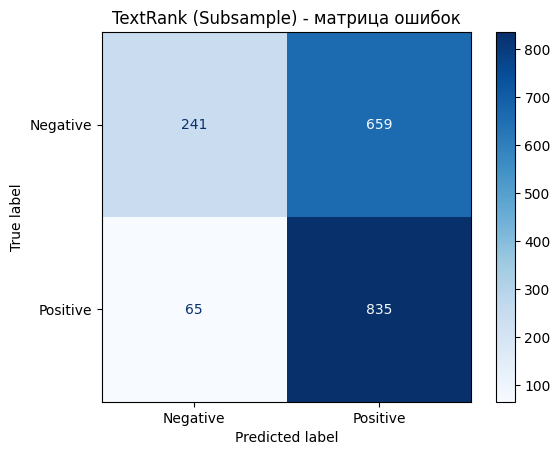

In [ ]:
sia_global = None

def init_worker():
    global sia_global
    sia_global = SentimentIntensityAnalyzer()

def textrank_sentiment_worker(text):
    # Если текст пустой или слишком короткий для графа
    if not isinstance(text, str) or len(text.split()) < 3:
        return 1

    tokens = text.split()
    window_size = 4
    cooc = defaultdict(lambda: defaultdict(int))

    # Построение графа совместной встречаемости
    for i, word in enumerate(tokens):
        for j in range(i + 1, min(i + window_size, len(tokens))):
            other = tokens[j]
            if word != other:
                cooc[word][other] += 1
                cooc[other][word] += 1

    G = nx.Graph()
    for word, neighbors in cooc.items():
        for other, weight in neighbors.items():
            G.add_edge(word, other, weight=weight)

    if len(G.nodes) == 0:
        return 1

    try:
        pagerank = nx.pagerank(G, weight='weight', max_iter=100)
    except:
        return 1

    top_words = sorted(pagerank, key=pagerank.get, reverse=True)[:10]
    res_text = ' '.join(top_words)
    score = sia_global.polarity_scores(res_text)['compound']

    return 1 if score >= 0 else 0

texts_sub = sub_test['clean_text'].tolist()
start_time = time.time()

print(f"Запуск TextRank на подвыборке: {len(texts_sub)} текстов")
print(f"Используется ядер: {cpu_count()}")

# Параллельный расчет
with Pool(processes=cpu_count(), initializer=init_worker) as pool:
    results_sub = list(tqdm(
        pool.imap(textrank_sentiment_worker, texts_sub, chunksize=100),
        total=len(texts_sub),
        desc="Обработка TextRank"
    ))

textrank_time_sub = time.time() - start_time

y_true_sub = sub_test['Sentiment']
y_pred_sub = results_sub

textrank_f1_sub = f1_score(y_true_sub, y_pred_sub, average='macro')
textrank_auc_sub = roc_auc_score(y_true_sub, y_pred_sub)

print(f"\nВремя выполнения: {textrank_time_sub:.2f} сек.")
print(f"F1-macro: {textrank_f1_sub:.3f}")
print(f"ROC-AUC: {textrank_auc_sub:.3f}")
print("\n", classification_report(y_true_sub, y_pred_sub, target_names=['Negative', 'Positive']))

cm = confusion_matrix(y_true_sub, y_pred_sub)
disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')
plt.title('TextRank (Subsample) - матрица ошибок')
plt.show()

## 3.3 TF-IDF + Logistic Regression

### На всём датасете

Начало векторизации
Размер матрицы признаков (train): (367210, 50000)
Время обучения: 5.25 сек.

F1-macro Train: 0.893
F1-macro Val:   0.875
Разрыв (Train-Val): 0.018
F1-macro: 0.872
ROC-AUC: 0.975
              precision    recall  f1-score   support

    Negative       0.69      0.92      0.79     12258
    Positive       0.98      0.93      0.95     66431

    accuracy                           0.92     78689
   macro avg       0.84      0.92      0.87     78689
weighted avg       0.94      0.92      0.93     78689



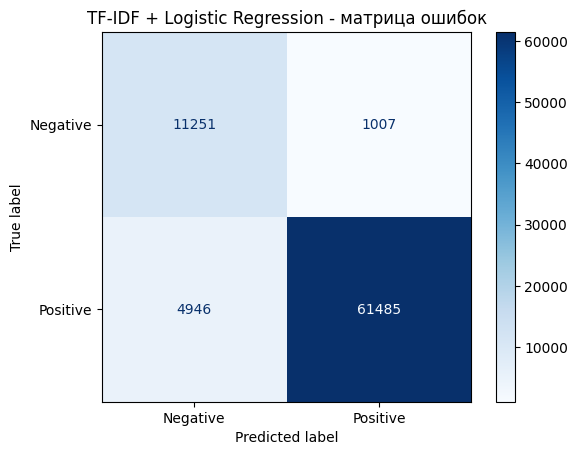

In [ ]:
# Векторизация (TF-IDF)
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1,2))

print("Начало векторизации")
X_train = tfidf.fit_transform(train_df['clean_text'])
X_val   = tfidf.transform(val_df['clean_text'])
X_test  = tfidf.transform(test_df['clean_text'])

y_train = train_df['Sentiment']
y_val   = val_df['Sentiment']
y_test  = test_df['Sentiment']

print("Размер матрицы признаков (train):", X_train.shape)

# Обучение модели
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1)

start_time = time.time()
lr_model.fit(X_train, y_train)
tfidf_lr_time = time.time() - start_time
print(f"Время обучения: {tfidf_lr_time:.2f} сек.\n")

y_train_pred = lr_model.predict(X_train)
y_val_pred = lr_model.predict(X_val)

f1_train = f1_score(y_train, y_train_pred, average='macro')
f1_val   = f1_score(y_val, y_val_pred, average='macro')

print(f"F1-macro Train: {f1_train:.3f}")
print(f"F1-macro Val:   {f1_val:.3f}")
print(f"Разрыв (Train-Val): {f1_train - f1_val:.3f}")

y_test_pred = lr_model.predict(X_test)
y_test_prob = lr_model.predict_proba(X_test)[:, 1]

tfidf_lr_f1 = f1_score(y_test, y_test_pred, average='macro')
tfidf_lr_auc = roc_auc_score(y_test, y_test_prob)

print(f"F1-macro: {tfidf_lr_f1:.3f}")
print(f"ROC-AUC: {tfidf_lr_auc:.3f}")
print(classification_report(y_test, y_test_pred, target_names=['Negative', 'Positive']))

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')
plt.title('TF-IDF + Logistic Regression - матрица ошибок')
plt.show()

### На подвыборке

Векторизация
Время обучения: 0.28 сек.
F1-macro Train: 0.925
F1-macro Val:   0.872

F1-macro: 0.860
ROC-AUC: 0.940

               precision    recall  f1-score   support

    Negative       0.86      0.87      0.86       900
    Positive       0.86      0.85      0.86       900

    accuracy                           0.86      1800
   macro avg       0.86      0.86      0.86      1800
weighted avg       0.86      0.86      0.86      1800



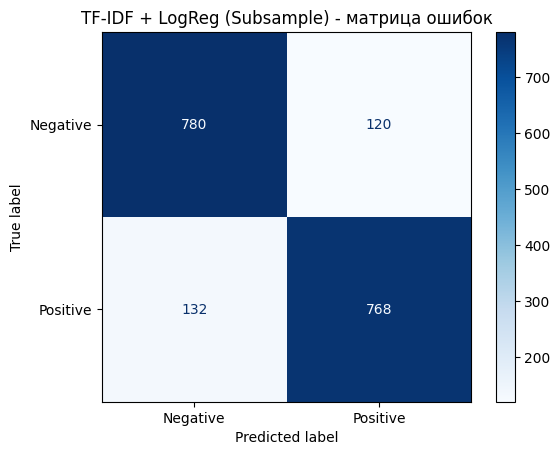

In [ ]:
# Векторизация
tfidf_sub = TfidfVectorizer(max_features=10000, ngram_range=(1,2))

print("Векторизация")
X_train_sub = tfidf_sub.fit_transform(sub_train['clean_text'])
X_val_sub   = tfidf_sub.transform(sub_val['clean_text'])
X_test_sub  = tfidf_sub.transform(sub_test['clean_text'])

y_train_sub = sub_train['Sentiment']
y_val_sub   = sub_val['Sentiment']
y_test_sub  = sub_test['Sentiment']

# Обучение
lr_sub = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

start_time = time.time()
lr_sub.fit(X_train_sub, y_train_sub)
tfidf_lr_time_sub = time.time() - start_time

# Проверка переобучения
y_train_pred_sub = lr_sub.predict(X_train_sub)
y_val_pred_sub = lr_sub.predict(X_val_sub)

f1_train_sub = f1_score(y_train_sub, y_train_pred_sub, average='macro')
f1_val_sub   = f1_score(y_val_sub, y_val_pred_sub, average='macro')

print(f"Время обучения: {tfidf_lr_time_sub:.2f} сек.")
print(f"F1-macro Train: {f1_train_sub:.3f}")
print(f"F1-macro Val:   {f1_val_sub:.3f}\n")

y_test_pred_sub = lr_sub.predict(X_test_sub)
y_test_prob_sub = lr_sub.predict_proba(X_test_sub)[:, 1]

tfidf_lr_f1_sub = f1_score(y_test_sub, y_test_pred_sub, average='macro')
tfidf_lr_auc_sub = roc_auc_score(y_test_sub, y_test_prob_sub)

print(f"F1-macro: {tfidf_lr_f1_sub:.3f}")
print(f"ROC-AUC: {tfidf_lr_auc_sub:.3f}")
print("\n", classification_report(y_test_sub, y_test_pred_sub, target_names=['Negative', 'Positive']))

cm = confusion_matrix(y_test_sub, y_test_pred_sub)
disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')
plt.title('TF-IDF + LogReg (Subsample) - матрица ошибок')
plt.show()

### Подбор гиперпараметров

In [ ]:
# Пространство поиска параметров
param_grid = {
    'C': [0.1, 1.0, 10.0], # сила регуляризации
    'penalty': ['l1', 'l2'], # тип штрафа
    'solver': ['liblinear']
}

grid_search = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000),
    param_grid,
    cv=3,
    scoring='f1_macro',
    verbose=1
)

print("Запуск подбора")
start_grid_time = time.time()
grid_search.fit(X_train_sub, y_train_sub)
grid_time = time.time() - start_grid_time

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший результат f1-macro: {grid_search.best_score_:.4f}")

Запуск подбора
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Лучшие параметры: {'C': 1.0, 'penalty': 'l2', 'solver': 'liblinear'}
Лучший результат f1-macro: 0.8563


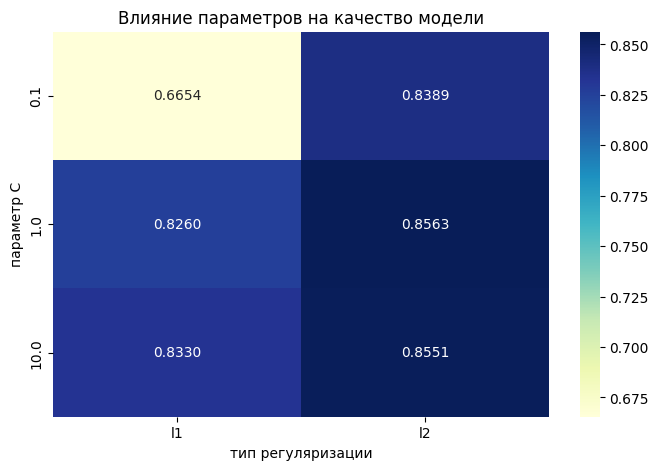

In [ ]:
results_df = pd.DataFrame(grid_search.cv_results_)
pivot_table = results_df.pivot(index='param_C', columns='param_penalty', values='mean_test_score')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='.4f')
plt.title('Влияние параметров на качество модели')
plt.xlabel('тип регуляризации')
plt.ylabel('параметр C')
plt.show()

best_lr_model = grid_search.best_estimator_

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


Время обучения: 14.08 сек.
f1-macro: 0.8752
roc-auc: 0.9756
              precision    recall  f1-score   support

           0       0.70      0.92      0.80     12258
           1       0.98      0.93      0.96     66431

    accuracy                           0.93     78689
   macro avg       0.84      0.92      0.88     78689
weighted avg       0.94      0.93      0.93     78689



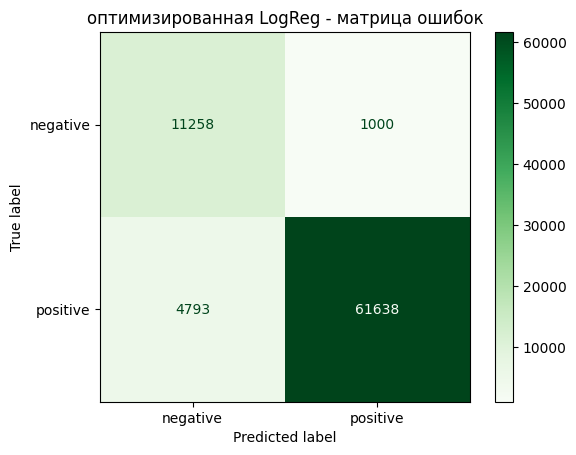

In [ ]:
# Модель с лучшими параметрами из grid search
best_lr_full = LogisticRegression(
    **grid_search.best_params_,
    class_weight='balanced',
    max_iter=1000,
    n_jobs=-1
)

# Обучение на полном наборе данных
start_best_lr = time.time()
best_lr_full.fit(X_train, y_train)
best_lr_time_full = time.time() - start_best_lr

print(f"Время обучения: {best_lr_time_full:.2f} сек.")

y_test_pred_best = best_lr_full.predict(X_test)
y_test_prob_best = best_lr_full.predict_proba(X_test)[:, 1]

best_lr_f1_full = f1_score(y_test, y_test_pred_best, average='macro')
best_lr_auc_full = roc_auc_score(y_test, y_test_prob_best)

print(f"f1-macro: {best_lr_f1_full:.4f}")
print(f"roc-auc: {best_lr_auc_full:.4f}")
print(classification_report(y_test, y_test_pred_best))

cm = confusion_matrix(y_test, y_test_pred_best)
ConfusionMatrixDisplay(cm, display_labels=['negative', 'positive']).plot(cmap='Greens')
plt.title('оптимизированная LogReg - матрица ошибок')
plt.show()

## 3.4 TF_IDF + SVM

### На всём датасете

Время обучения: 161.63 сек.
F1-macro Train: 0.956
F1-macro Val:   0.908

F1-macro Test: 0.906
ROC-AUC Test: 0.977

               precision    recall  f1-score   support

    Negative       0.87      0.81      0.84     12258
    Positive       0.97      0.98      0.97     66431

    accuracy                           0.95     78689
   macro avg       0.92      0.90      0.91     78689
weighted avg       0.95      0.95      0.95     78689



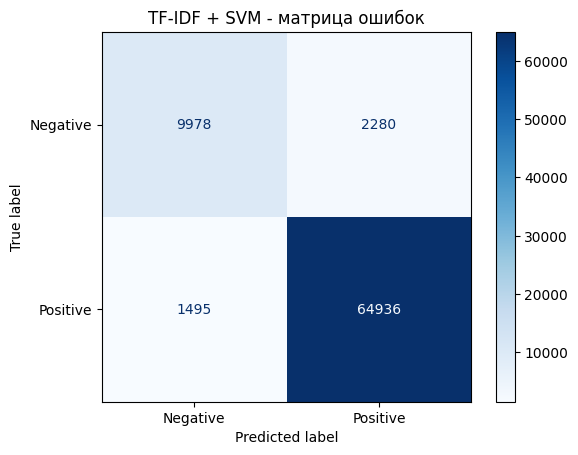

In [ ]:
# Обучение
svm = LinearSVC(class_weight='balanced', max_iter=1000, random_state=42)
svm_cal = CalibratedClassifierCV(svm)

start_time = time.time()
svm_cal.fit(X_train, y_train)
svm_time = time.time() - start_time

# Проверка переобучения
y_train_pred = svm_cal.predict(X_train)
f1_train = f1_score(y_train, y_train_pred, average='macro')
f1_val = f1_score(y_val, svm_cal.predict(X_val), average='macro')

print(f"Время обучения: {svm_time:.2f} сек.")
print(f"F1-macro Train: {f1_train:.3f}")
print(f"F1-macro Val:   {f1_val:.3f}")

y_test_pred = svm_cal.predict(X_test)
y_test_prob = svm_cal.predict_proba(X_test)[:, 1]

svm_f1 = f1_score(y_test, y_test_pred, average='macro')
svm_auc = roc_auc_score(y_test, y_test_prob)

print(f"\nF1-macro Test: {svm_f1:.3f}")
print(f"ROC-AUC Test: {svm_auc:.3f}")
print("\n", classification_report(y_test, y_test_pred, target_names=['Negative', 'Positive']))

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')
plt.title('TF-IDF + SVM - матрица ошибок')
plt.show()

Снижение переобучения:

Время обучения: 69.27 сек.
F1-macro Train: 0.919
F1-macro Val:   0.898

F1-macro Test: 0.895
ROC-AUC Test: 0.976

               precision    recall  f1-score   support

    Negative       0.85      0.79      0.82     12258
    Positive       0.96      0.97      0.97     66431

    accuracy                           0.95     78689
   macro avg       0.91      0.88      0.90     78689
weighted avg       0.95      0.95      0.95     78689



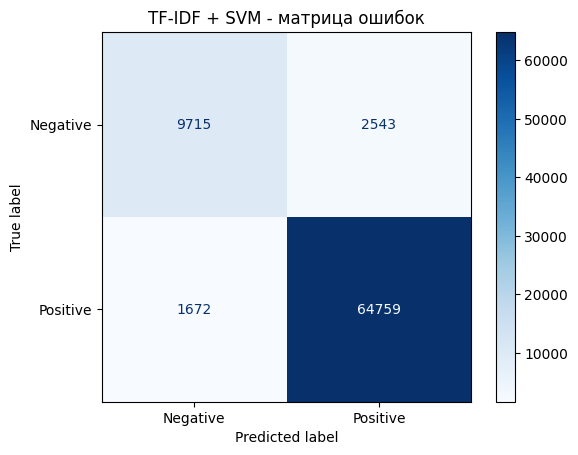

In [ ]:
# Обучение
svm = LinearSVC(C=0.1, class_weight='balanced', max_iter=1000, random_state=42)
svm_cal = CalibratedClassifierCV(svm)

start_time = time.time()
svm_cal.fit(X_train, y_train)
svm_time = time.time() - start_time

# Проверка переобучения
y_train_pred = svm_cal.predict(X_train)
f1_train = f1_score(y_train, y_train_pred, average='macro')
f1_val = f1_score(y_val, svm_cal.predict(X_val), average='macro')

print(f"Время обучения: {svm_time:.2f} сек.")
print(f"F1-macro Train: {f1_train:.3f}")
print(f"F1-macro Val:   {f1_val:.3f}")

y_test_pred = svm_cal.predict(X_test)
y_test_prob = svm_cal.predict_proba(X_test)[:, 1]

svm_f1 = f1_score(y_test, y_test_pred, average='macro')
svm_auc = roc_auc_score(y_test, y_test_prob)

print(f"\nF1-macro Test: {svm_f1:.3f}")
print(f"ROC-AUC Test: {svm_auc:.3f}")
print("\n", classification_report(y_test, y_test_pred, target_names=['Negative', 'Positive']))

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')
plt.title('TF-IDF + SVM - матрица ошибок')
plt.show()

### На подвыборке

Время обучения: 1.02 сек.
F1-macro (Sub): 0.857
ROC-AUC (Sub): 0.940

               precision    recall  f1-score   support

    Negative       0.85      0.86      0.86       900
    Positive       0.86      0.85      0.86       900

    accuracy                           0.86      1800
   macro avg       0.86      0.86      0.86      1800
weighted avg       0.86      0.86      0.86      1800



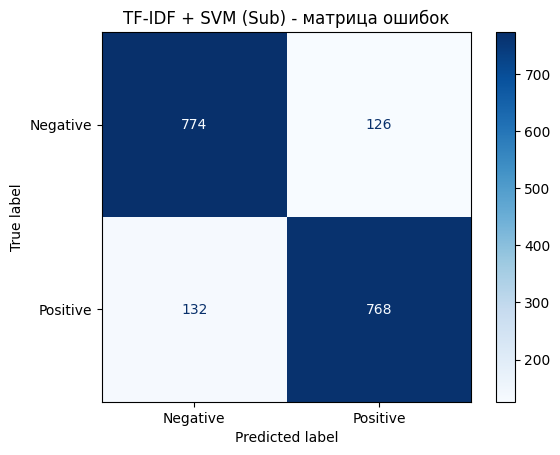

In [ ]:
# Обучение на подвыборке
svm_sub = LinearSVC(C=0.1, class_weight='balanced', max_iter=1000, random_state=42)
svm_cal_sub = CalibratedClassifierCV(svm_sub)

start_time = time.time()
svm_cal_sub.fit(X_train_sub, y_train_sub)
svm_time_sub = time.time() - start_time

y_test_pred_sub = svm_cal_sub.predict(X_test_sub)
y_test_prob_sub = svm_cal_sub.predict_proba(X_test_sub)[:, 1]

svm_f1_sub = f1_score(y_test_sub, y_test_pred_sub, average='macro')
svm_auc_sub = roc_auc_score(y_test_sub, y_test_prob_sub)

print(f"Время обучения: {svm_time_sub:.2f} сек.")
print(f"F1-macro (Sub): {svm_f1_sub:.3f}")
print(f"ROC-AUC (Sub): {svm_auc_sub:.3f}")
print("\n", classification_report(y_test_sub, y_test_pred_sub, target_names=['Negative', 'Positive']))


cm = confusion_matrix(y_test_sub, y_test_pred_sub)
disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')
plt.title('TF-IDF + SVM (Sub) - матрица ошибок')
plt.show()

## 3.5 LSTM

### На всём датасете

Размер словаря: 30002
LSTMClassifier(
  (embedding): Embedding(30002, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)


Epoch 1/5 | Train Loss: 0.1347 F1: 0.7051 | Val Loss: 0.0883 F1: 0.8515


Epoch 2/5 | Train Loss: 0.0778 F1: 0.8300 | Val Loss: 0.0655 F1: 0.8406


Epoch 3/5 | Train Loss: 0.0612 F1: 0.8654 | Val Loss: 0.0546 F1: 0.8937


Epoch 4/5 | Train Loss: 0.0517 F1: 0.8859 | Val Loss: 0.0548 F1: 0.9190


Epoch 5/5 | Train Loss: 0.0452 F1: 0.8995 | Val Loss: 0.0514 F1: 0.9189
Время обучения модели: 714.5164723396301


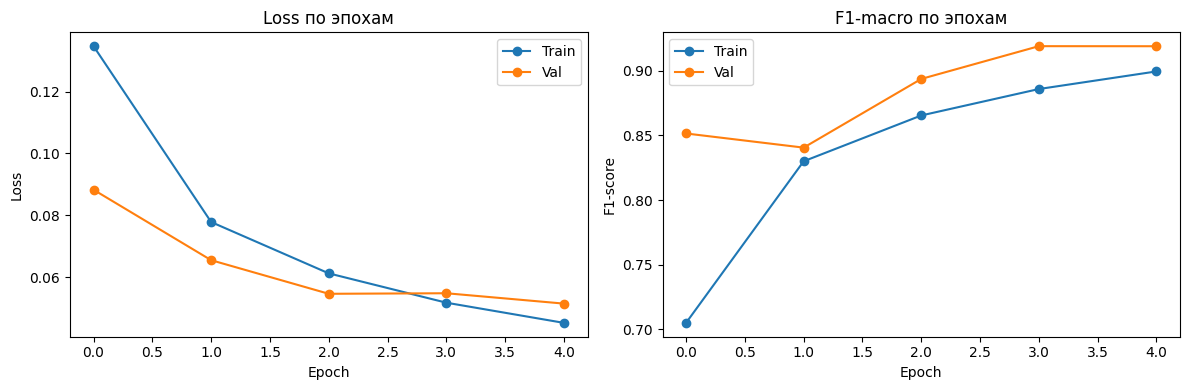


Test
              precision    recall  f1-score   support

    Negative       0.81      0.92      0.86     12258
    Positive       0.98      0.96      0.97     66431

    accuracy                           0.95     78689
   macro avg       0.90      0.94      0.92     78689
weighted avg       0.96      0.95      0.95     78689

F1-macro: 0.916
ROC-AUC: 0.986


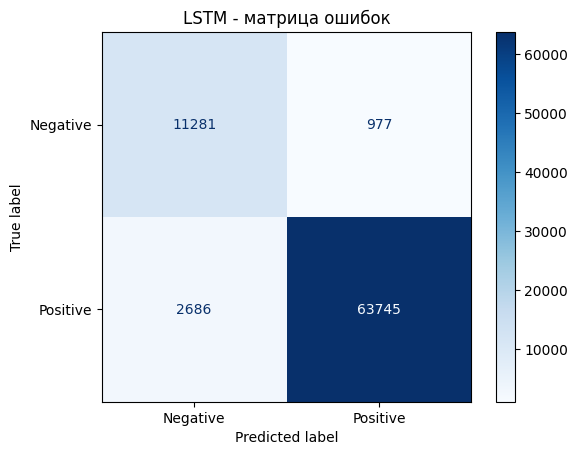

In [ ]:
# Словарь
MAX_VOCAB = 30000
MAX_LEN = 150

all_words = ' '.join(train_df['light_text']).split()
vocab_counter = Counter(all_words)
most_common = vocab_counter.most_common(MAX_VOCAB)

word2idx = {'<PAD>': 0, '<UNK>': 1}
for word, _ in most_common:
    word2idx[word] = len(word2idx)

print(f"Размер словаря: {len(word2idx)}")

# Dataset
class ReviewDataset(Dataset):
    def __init__(self, df):
        self.texts  = df['light_text'].tolist()
        self.labels = df['Sentiment'].tolist()

    def encode(self, text):
        tokens = text.split()[:MAX_LEN]
        ids = [word2idx.get(w, 1) for w in tokens]
        ids += [0] * (MAX_LEN - len(ids))
        return torch.tensor(ids, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.encode(self.texts[idx]), torch.tensor(self.labels[idx], dtype=torch.float)

train_dataset = ReviewDataset(train_df)
val_dataset = ReviewDataset(val_df)
test_dataset = ReviewDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256)
test_loader = DataLoader(test_dataset, batch_size=256)

# Модель
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim,
                            num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0,
                            bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(emb)
        hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        return self.fc(self.dropout(hidden)).squeeze(1)

model = LSTMClassifier(
    vocab_size = len(word2idx),
    embed_dim = 128,
    hidden_dim = 128,
    num_layers = 2,
    dropout = 0.3
).to(device)

print(model)

# Обучение
pos_weight = torch.tensor([len(train_df[train_df['Sentiment']==0]) /
                            len(train_df[train_df['Sentiment']==1])]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, total = 0, 0
    all_preds, all_labels = [], []
    pbar = tqdm(loader, desc='Training' if train else 'Evaluating', leave=False)
    with torch.set_grad_enabled(train):
        for X, y in pbar:
            X, y = X.to(device), y.to(device)
            out  = model(X)
            loss = criterion(out, y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            preds = (torch.sigmoid(out) >= 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            total += y.size(0)
            total_loss += loss.item() * y.size(0)
    return total_loss / total, f1_score(all_labels, all_preds, average='macro')

EPOCHS = 5
history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}

start_train_time = time.time()
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_f1'].append(train_acc)
    history['val_f1'].append(val_acc)

    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {train_loss:.4f} F1: {train_acc:.4f} | Val Loss: {val_loss:.4f} F1: {val_acc:.4f}")

lstm_time = time.time() - start_train_time
print("Время обучения модели:", lstm_time)

# Графики обучения
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], 'o-', label='Train')
axes[0].plot(history['val_loss'], 'o-', label='Val')
axes[0].set_title('Loss по эпохам')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history['train_f1'], 'o-', label='Train')
axes[1].plot(history['val_f1'], 'o-', label='Val')
axes[1].set_title('F1-macro по эпохам')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1-score')
axes[1].legend()

plt.tight_layout()
plt.show()

model.eval()
all_preds, all_probs, all_labels = [], [], []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        out = model(X)
        probs = torch.sigmoid(out).cpu().numpy()
        preds = (probs >= 0.5).astype(int)
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

lstm_f1 = f1_score(all_labels, all_preds, average='macro')
lstm_auc = roc_auc_score(all_labels, all_probs)

print("\nTest")
print(classification_report(all_labels, all_preds, target_names=['Negative', 'Positive']))
print(f"F1-macro: {lstm_f1:.3f}")
print("ROC-AUC:", lstm_auc.round(3))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')
plt.title('LSTM - матрица ошибок')
plt.show()

### На подвыборке

Размер словаря: 30002
LSTMClassifier(
  (embedding): Embedding(30002, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)


Epoch 1/5 | Train Loss: 0.6724 F1: 0.5777 | Val Loss: 0.6249 F1: 0.6622


Epoch 2/5 | Train Loss: 0.6242 F1: 0.6614 | Val Loss: 0.6190 F1: 0.6507


Epoch 3/5 | Train Loss: 0.5807 F1: 0.6952 | Val Loss: 0.5483 F1: 0.7215


Epoch 4/5 | Train Loss: 0.5275 F1: 0.7391 | Val Loss: 0.5147 F1: 0.7575


Epoch 5/5 | Train Loss: 0.4926 F1: 0.7641 | Val Loss: 0.4998 F1: 0.7653
Время обучения модели: 14.29579782485962


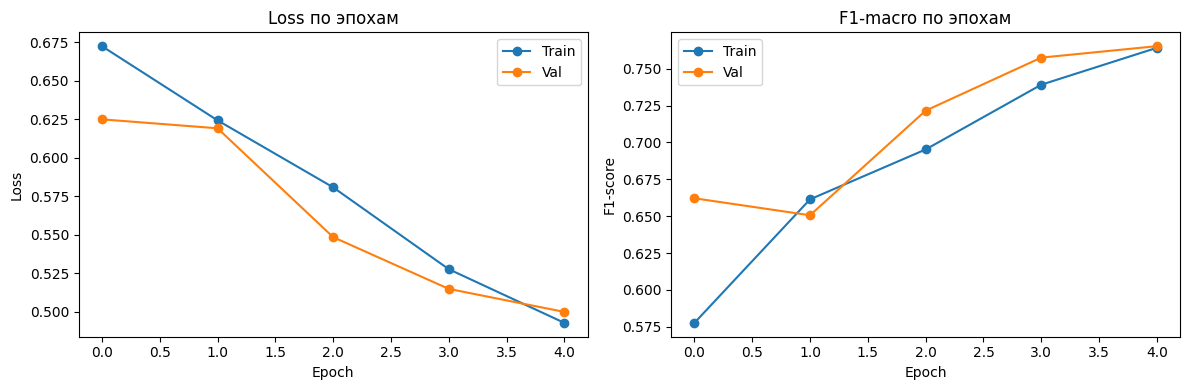


Test
              precision    recall  f1-score   support

    Negative       0.81      0.70      0.75       900
    Positive       0.73      0.84      0.78       900

    accuracy                           0.77      1800
   macro avg       0.77      0.77      0.77      1800
weighted avg       0.77      0.77      0.77      1800

F1-macro: 0.766
ROC-AUC: 0.852


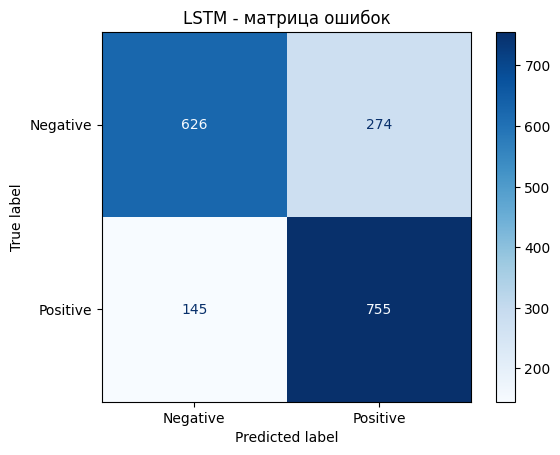

In [ ]:
# Словарь
MAX_VOCAB = 30000
MAX_LEN = 150

all_words = ' '.join(train_df['light_text']).split()
vocab_counter = Counter(all_words)
most_common = vocab_counter.most_common(MAX_VOCAB)

word2idx = {'<PAD>': 0, '<UNK>': 1}
for word, _ in most_common:
    word2idx[word] = len(word2idx)

print(f"Размер словаря: {len(word2idx)}")

# Dataset
class ReviewDataset(Dataset):
    def __init__(self, df):
        self.texts  = df['light_text'].tolist()
        self.labels = df['Sentiment'].tolist()

    def encode(self, text):
        tokens = text.split()[:MAX_LEN]
        ids = [word2idx.get(w, 1) for w in tokens]
        ids += [0] * (MAX_LEN - len(ids))
        return torch.tensor(ids, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.encode(self.texts[idx]), torch.tensor(self.labels[idx], dtype=torch.float)

train_dataset = ReviewDataset(sub_train)
val_dataset = ReviewDataset(sub_val)
test_dataset  = ReviewDataset(sub_test)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256)
test_loader = DataLoader(test_dataset, batch_size=256)

# Модель
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim,
                            num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0,
                            bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(emb)
        hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        return self.fc(self.dropout(hidden)).squeeze(1)

model = LSTMClassifier(
    vocab_size  = len(word2idx),
    embed_dim   = 128,
    hidden_dim  = 128,
    num_layers  = 2,
    dropout     = 0.3
).to(device)

print(model)

# Обучение
pos_weight = torch.tensor([len(sub_train[sub_train['Sentiment']==0]) /
                            len(sub_train[sub_train['Sentiment']==1])]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, total = 0, 0
    all_preds, all_labels = [], []
    pbar = tqdm(loader, desc='Training' if train else 'Evaluating', leave=False)
    with torch.set_grad_enabled(train):
        for X, y in pbar:
            X, y = X.to(device), y.to(device)
            out  = model(X)
            loss = criterion(out, y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            preds = (torch.sigmoid(out) >= 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            total   += y.size(0)
            total_loss += loss.item() * y.size(0)
    return total_loss / total, f1_score(all_labels, all_preds, average='macro')

EPOCHS = 5
history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}

start_train_time = time.time()
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss,   val_acc   = run_epoch(val_loader,   train=False)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_f1'].append(train_acc)
    history['val_f1'].append(val_acc)

    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {train_loss:.4f} F1: {train_acc:.4f} | Val Loss: {val_loss:.4f} F1: {val_acc:.4f}")

lstm_time_sub = time.time() - start_train_time
print("Время обучения модели:", lstm_time_sub)

# Графики обучения
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], 'o-', label='Train')
axes[0].plot(history['val_loss'],   'o-', label='Val')
axes[0].set_title('Loss по эпохам')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history['train_f1'], 'o-', label='Train')
axes[1].plot(history['val_f1'], 'o-', label='Val')
axes[1].set_title('F1-macro по эпохам')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1-score')
axes[1].legend()

plt.tight_layout()
plt.show()

model.eval()
all_preds, all_probs, all_labels = [], [], []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        out   = model(X)
        probs = torch.sigmoid(out).cpu().numpy()
        preds = (probs >= 0.5).astype(int)
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

lstm_f1_sub = f1_score(all_labels, all_preds, average='macro')
lstm_auc_sub = roc_auc_score(all_labels, all_probs)

print("\nTest")
print(classification_report(all_labels, all_preds, target_names=['Negative', 'Positive']))
print(f"F1-macro: {lstm_f1_sub:.3f}")
print("ROC-AUC:", lstm_auc_sub.round(3))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')
plt.title('LSTM - матрица ошибок')
plt.show()

### Подбор гиперпараметров

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

tune_train_loader = DataLoader(ReviewDataset(sub_train), batch_size=256, shuffle=True)
tune_val_loader = DataLoader(ReviewDataset(sub_val), batch_size=256)

def objective(trial: Trial):
    h_dim = trial.suggest_categorical('hidden_dim', [64, 128])
    drop = trial.suggest_float('dropout', 0.2, 0.5, step=0.1)
    learning_rate = trial.suggest_float('lr', 1e-4, 1e-3, log=True)
    n_layers = trial.suggest_int('num_layers', 1, 2)

    model_tune = LSTMClassifier(
        vocab_size = len(word2idx),
        embed_dim = 128,
        hidden_dim = h_dim,
        num_layers = n_layers,
        dropout = drop
    ).to(device)

    optimizer_tune = torch.optim.Adam(model_tune.parameters(), lr=learning_rate)
    criterion_tune = nn.BCEWithLogitsLoss()

    for epoch in range(3):
        model_tune.train()
        for x_batch, y_batch in tune_train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            out = model_tune(x_batch)
            loss = criterion_tune(out, y_batch)
            optimizer_tune.zero_grad()
            loss.backward()
            optimizer_tune.step()

    model_tune.eval()
    preds_list, true_list = [], []
    with torch.no_grad():
        for x_batch, y_batch in tune_val_loader:
            x_batch = x_batch.to(device)
            out = model_tune(x_batch)
            preds = (torch.sigmoid(out) >= 0.5).cpu().numpy()
            preds_list.extend(preds)
            true_list.extend(y_batch.numpy())

    return f1_score(true_list, preds_list, average='macro')

print("Начало подбора")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10, show_progress_bar=True)

print("\nОптимальные настройки:")
print(study.best_params)
print(f"Лучший результат на валидации: {study.best_value:.4f}")

Начало подбора


  0%|          | 0/10 [00:00<?, ?it/s]


Оптимальные настройки:
{'hidden_dim': 128, 'dropout': 0.2, 'lr': 0.0006625165828658919, 'num_layers': 2}
Лучший результат на валидации: 0.7491


In [ ]:
# переобучение финальной модели с лучшими параметрами
best_params = study.best_params

final_lstm = LSTMClassifier(
    vocab_size = len(word2idx),
    embed_dim = 128,
    hidden_dim = best_params['hidden_dim'],
    num_layers = best_params['num_layers'],
    dropout = best_params['dropout']
).to(device)

final_optimizer = torch.optim.Adam(final_lstm.parameters(), lr=best_params['lr'])
final_criterion = nn.BCEWithLogitsLoss()

print("Обучение финальной модели")
for epoch in range(1, 6):
    train_l, train_a = run_epoch(train_loader, train=True)
    val_l, val_a = run_epoch(val_loader, train=False)
    print(f"Эпоха {epoch} - результат F-macro на валидации: {val_a:.4f}")

Обучение финальной модели


Эпоха 1 - результат F-macro на валидации: 0.7844


Эпоха 2 - результат F-macro на валидации: 0.8028


Эпоха 3 - результат F-macro на валидации: 0.8178


Эпоха 4 - результат F-macro на валидации: 0.8150


Эпоха 5 - результат F-macro на валидации: 0.8444


## 3.6 SAGE

### На подвыборке

Обучение


edgesage: 100%|██████████| 200/200 [00:02<00:00, 73.25it/s, loss=0.6925, f_val=0.500]


Время обучения 2.739


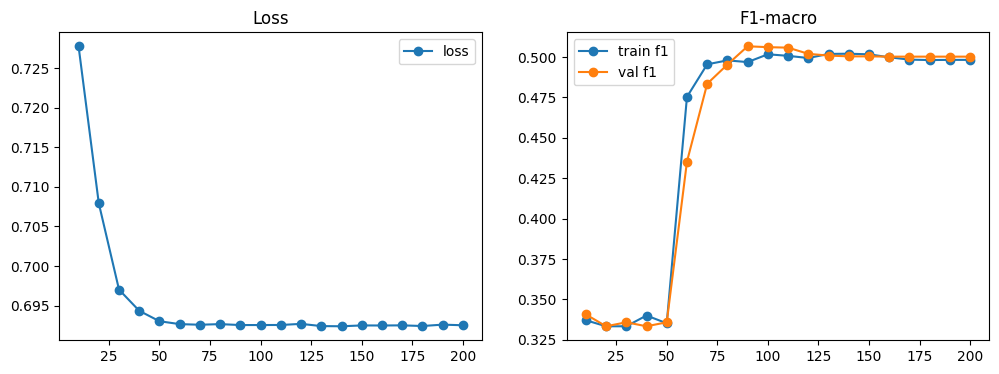

F_macro: 0.497
ROC-AUC: 0.513
              precision    recall  f1-score   support

           0       0.52      0.34      0.41       900
           1       0.51      0.69      0.58       900

    accuracy                           0.51      1800
   macro avg       0.51      0.51      0.50      1800
weighted avg       0.51      0.51      0.50      1800



In [ ]:
all_sub_data = pd.concat([sub_train, sub_val, sub_test]).reset_index(drop=True)

# Кодирование пользователей и продуктов
user_encoder = LabelEncoder()
prod_encoder = LabelEncoder()

user_encoder.fit(all_sub_data['UserId'])
prod_encoder.fit(all_sub_data['ProductId'])

n_users = len(user_encoder.classes_)
n_prods = len(prod_encoder.classes_)
node_offset = n_users

def prepare_graph_data(df):
    u_idx = user_encoder.transform(df['UserId'])
    p_idx = prod_encoder.transform(df['ProductId']) + node_offset

    src = torch.tensor(u_idx, dtype=torch.long)
    dst = torch.tensor(p_idx, dtype=torch.long)

    edge_index = torch.stack([
        torch.cat([src, dst]),
        torch.cat([dst, src])
    ], dim=0)

    labels = torch.tensor(df['Sentiment'].values, dtype=torch.long)
    return edge_index, labels

# Наборы ребер для каждой выборки
train_ei, train_lab = prepare_graph_data(sub_train)
val_ei, val_lab = prepare_graph_data(sub_val)
test_ei, test_lab = prepare_graph_data(sub_test)

u_counts = all_sub_data.groupby('UserId').size().reindex(user_encoder.classes_, fill_value=0).values
p_counts = all_sub_data.groupby('ProductId').size().reindex(prod_encoder.classes_, fill_value=0).values

u_feat = np.stack([u_counts / (u_counts.max() + 1e-9), np.ones(n_users)], axis=1)
p_feat = np.stack([p_counts / (p_counts.max() + 1e-9), np.zeros(n_prods)], axis=1)

x_nodes = torch.tensor(np.vstack([u_feat, p_feat]), dtype=torch.float).to(device)

class EdgeSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.3):
        super().__init__()
        self.conv_first = SAGEConv(in_channels, hidden_channels)
        self.conv_second = SAGEConv(hidden_channels, hidden_channels)
        self.dropout = dropout
        self.classifier = nn.Linear(hidden_channels * 2, 2)

    def encode(self, x, edge_index):
        x = self.conv_first(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv_second(x, edge_index)
        return x

    def decode(self, z, edge_index):
        src_vectors = z[edge_index[0]]
        dst_vectors = z[edge_index[1]]
        combined = torch.cat([src_vectors, dst_vectors], dim=1)
        return self.classifier(combined)

    def forward(self, x, message_ei, predict_ei):
        z_embeddings = self.encode(x, message_ei)
        return self.decode(z_embeddings, predict_ei)

model_sage = EdgeSAGE(in_channels=2, hidden_channels=64).to(device)
optimizer = torch.optim.Adam(model_sage.parameters(), lr=0.01, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15)

t_ei_dev, t_lab_dev = train_ei.to(device), train_lab.to(device)
v_ei_dev = val_ei.to(device)
ts_ei_dev = test_ei.to(device)

def get_metrics(ei, labels_actual):
    model_sage.eval()
    with torch.no_grad():
        output = model_sage(x_nodes, t_ei_dev, ei)
        num_edges = labels_actual.shape[0]
        logits = output[:num_edges]
        predictions = logits.argmax(dim=1).cpu().numpy()
        probabilities = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
    return predictions, probabilities, labels_actual.numpy()

print("Обучение")
start_time_val = time.time()
history_sage = {'loss': [], 'train_f': [], 'val_f': []}
progress_bar = tqdm(range(1, 201), desc="edgesage")

for epoch in progress_bar:
    model_sage.train()
    optimizer.zero_grad()

    res = model_sage(x_nodes, t_ei_dev, t_ei_dev)
    n_t = train_lab.shape[0]
    loss_val = F.cross_entropy(res[:n_t], t_lab_dev)

    loss_val.backward()
    optimizer.step()
    scheduler.step(loss_val)

    if epoch % 10 == 0:
        vp, _, vt = get_metrics(v_ei_dev, val_lab)
        tp, _, tt = get_metrics(t_ei_dev, train_lab)

        f_v = f1_score(vt, vp, average='macro')
        f_t = f1_score(tt, tp, average='macro')

        history_sage['loss'].append(loss_val.item())
        history_sage['val_f'].append(f_v)
        history_sage['train_f'].append(f_t)
        progress_bar.set_postfix({'loss': f'{loss_val.item():.4f}', 'f_val': f'{f_v:.3f}'})

sage_time_sub = time.time() - start_time_val
print(f"Время обучения {sage_time_sub:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(range(10, 201, 10), history_sage['loss'], 'o-', label='loss')
ax[0].set_title('Loss'); ax[0].legend()
ax[1].plot(range(10, 201, 10), history_sage['train_f'], 'o-', label='train f1')
ax[1].plot(range(10, 201, 10), history_sage['val_f'], 'o-', label='val f1')
ax[1].set_title('F1-macro')
ax[1].legend()
plt.show()

final_p, final_prob, final_true = get_metrics(ts_ei_dev, test_lab)
sage_f1_sub = f1_score(final_true, final_p, average='macro')
sage_auc_sub = roc_auc_score(final_true, final_prob)

print(f"F_macro: {sage_f1_sub:.3f}")
print(f"ROC-AUC: {sage_auc_sub:.3f}")
print(classification_report(final_true, final_p))

## 3.7 TextGCN

### На подвыборке

Расчёт TF-IDF
Расчёт PMI


Создание рёбер PMI: 100%|██████████| 755132/755132 [00:03<00:00, 206072.54it/s]


Сжатие признаков SVD
Обучение модели


GCN Training: 100%|██████████| 200/200 [00:10<00:00, 18.45it/s]


Время обучения модели: 10.842


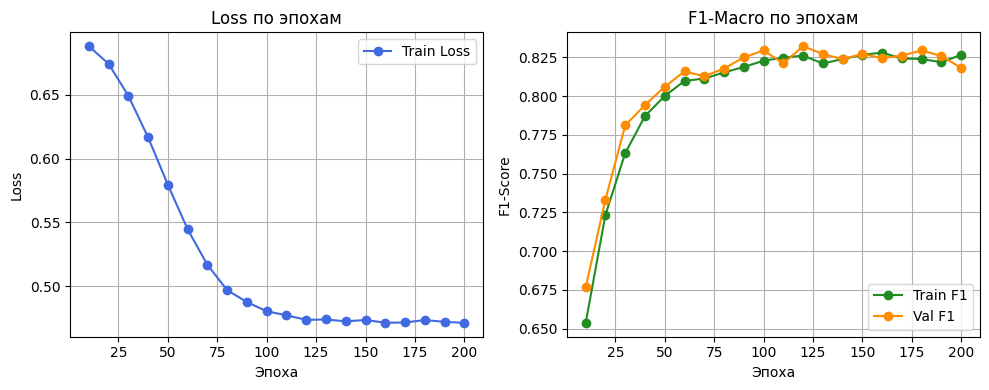


F1-macro: 0.828
ROC-AUC: 0.909
              precision    recall  f1-score   support

    Negative       0.80      0.88      0.84       900
    Positive       0.86      0.78      0.82       900

    accuracy                           0.83      1800
   macro avg       0.83      0.83      0.83      1800
weighted avg       0.83      0.83      0.83      1800



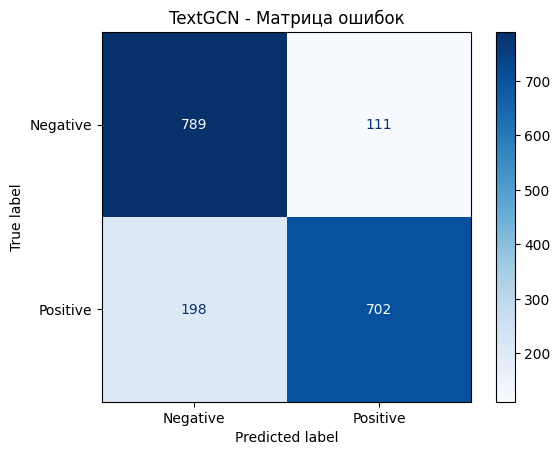

In [ ]:
# Объединение подвыборки в один граф
sub_all = pd.concat([sub_train, sub_val, sub_test]).reset_index(drop=True)
texts = sub_all['clean_text'].tolist()
labels = sub_all['Sentiment'].tolist()

n_docs = len(texts)
N_TRAIN = len(sub_train)
N_VAL = len(sub_val)
N_TEST = len(sub_test)

# Построение словаря и TF-IDF (документ-слово)
print("Расчёт TF-IDF")
tfidf_gcn = TfidfVectorizer(max_features=10000)
tfidf_mat = tfidf_gcn.fit_transform(texts)
vocab = tfidf_gcn.get_feature_names_out()
n_words = len(vocab)
word2id = {w: i for i, w in enumerate(vocab)}

# Расчёт PMI (слово-слово)
print("Расчёт PMI")
WINDOW = 5
word_freq = defaultdict(int)
pair_freq = defaultdict(int)
total_windows = 0

for text in tqdm(texts, desc="Анализ сонахождений"):
    tokens = text.split()
    for i in range(len(tokens)):
        window = tokens[i : i + WINDOW]
        for w in window:
            if w in word2id: word_freq[w] += 1
        for j in range(len(window)):
            for k in range(j + 1, len(window)):
                if window[j] in word2id and window[k] in word2id:
                    pair = tuple(sorted([window[j], window[k]]))
                    pair_freq[pair] += 1
        total_windows += 1

# Сборка рёбер графа
edge_index = []
edge_weight = []

# Рёбра документ-слово
cx = tfidf_mat.tocoo()
for doc_i, word_j, val in zip(cx.row, cx.col, cx.data):
    edge_index.append([doc_i, n_docs + word_j])
    edge_index.append([n_docs + word_j, doc_i])
    edge_weight.append(val)
    edge_weight.append(val)

# Рёбра слово-слово
for (w1, w2), freq in tqdm(pair_freq.items(), desc="Создание рёбер PMI"):
    pmi = np.log((freq / total_windows) /
                 (word_freq[w1] / total_windows) /
                 (word_freq[w2] / total_windows) + 1e-9)
    if pmi > 0:
        i1, i2 = n_docs + word2id[w1], n_docs + word2id[w2]
        edge_index.append([i1, i2])
        edge_index.append([i2, i1])
        edge_weight.append(pmi)
        edge_weight.append(pmi)

edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
edge_weight = torch.tensor(edge_weight, dtype=torch.float)

# Признаки узлов
print("Сжатие признаков SVD")
DIM = 200
svd = TruncatedSVD(n_components=DIM, random_state=42)
doc_feat = svd.fit_transform(tfidf_mat)
word_feat = svd.fit_transform(tfidf_mat.T)
x = torch.tensor(np.vstack([doc_feat, word_feat]), dtype=torch.float)

# Маски и данные
y = torch.tensor(labels, dtype=torch.long)
train_mask = torch.zeros(n_docs + n_words, dtype=torch.bool)
val_mask = torch.zeros(n_docs + n_words, dtype=torch.bool)
test_mask = torch.zeros(n_docs + n_words, dtype=torch.bool)

train_mask[:N_TRAIN] = True
val_mask[N_TRAIN : N_TRAIN + N_VAL] = True
test_mask[N_TRAIN + N_VAL : n_docs] = True

data = Data(x=x, edge_index=edge_index, edge_attr=edge_weight, y=y,
            train_mask=train_mask, val_mask=val_mask, test_mask=test_mask).to(device)

# Архитектура GCN
class TextGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index, edge_weight):
        x = self.conv1(x, edge_index, edge_weight)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index, edge_weight)
        return x

model_gcn = TextGCN(DIM, 128, 2).to(device)
optimizer = torch.optim.Adam(model_gcn.parameters(), lr=0.01, weight_decay=5e-4)

# Обучение
print("Обучение модели")
start_gcn_time = time.time()

history_gcn = {'train_loss': [], 'val_f1': [], 'train_f1': []}

for epoch in tqdm(range(1, 201), desc="GCN Training"):
    model_gcn.train()
    optimizer.zero_grad()
    out = model_gcn(data.x, data.edge_index, data.edge_attr)
    logits_docs = out[:n_docs]
    loss = F.cross_entropy(logits_docs[data.train_mask[:n_docs]],
                           data.y[data.train_mask[:n_docs]])
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        model_gcn.eval()
        with torch.no_grad():
            preds = logits_docs.argmax(dim=1).cpu().numpy()
            y_true_all = data.y.cpu().numpy()

            train_m = data.train_mask[:n_docs].cpu().numpy()
            val_m   = data.val_mask[:n_docs].cpu().numpy()

            f1_train = f1_score(y_true_all[train_m], preds[train_m], average='macro')
            f1_val   = f1_score(y_true_all[val_m], preds[val_m], average='macro')

            history_gcn['train_loss'].append(loss.item())
            history_gcn['train_f1'].append(f1_train)
            history_gcn['val_f1'].append(f1_val)

text_gcn_time_sub = time.time() - start_gcn_time
print(f"Время обучения модели: {text_gcn_time_sub:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(range(10, 201, 10), history_gcn['train_loss'], 'o-', label='Train Loss', color='royalblue')
axes[0].set_title('Loss по эпохам')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].grid(True)
axes[0].legend()

axes[1].plot(range(10, 201, 10), history_gcn['train_f1'], 'o-', label='Train F1', color='forestgreen')
axes[1].plot(range(10, 201, 10), history_gcn['val_f1'], 'o-', label='Val F1', color='darkorange')
axes[1].set_title('F1-Macro по эпохам')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('F1-Score')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

# Оценка
model_gcn.eval()
with torch.no_grad():
    logits = model_gcn(data.x, data.edge_index, data.edge_attr)
    test_logits = logits[data.test_mask]
    test_preds = test_logits.argmax(dim=1).cpu().numpy()
    test_probs = F.softmax(test_logits, dim=1)[:, 1].cpu().numpy()
    y_true = data.y[data.test_mask[:n_docs]].cpu().numpy()

text_gcn_f1_sub = f1_score(y_true, test_preds, average='macro')
text_gcn_auc_sub = roc_auc_score(y_true, test_probs)

print(f"\nF1-macro: {text_gcn_f1_sub:.3f}")
print(f"ROC-AUC: {text_gcn_auc_sub:.3f}")
print(classification_report(y_true, test_preds, target_names=['Negative', 'Positive']))

cm = confusion_matrix(y_true, test_preds)
ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive']).plot(cmap='Blues')
plt.title('TextGCN - Матрица ошибок')
plt.show()

### На большей подвыборке

Документов в графе: 28000
Расчёт TF-IDF
Расчёт PMI


Создание рёбер: 100%|██████████| 1045720/1045720 [00:07<00:00, 132232.35it/s]


Обучение модели


GCN Training: 100%|██████████| 200/200 [00:18<00:00, 10.90it/s]

Время обучения модели: 18.355


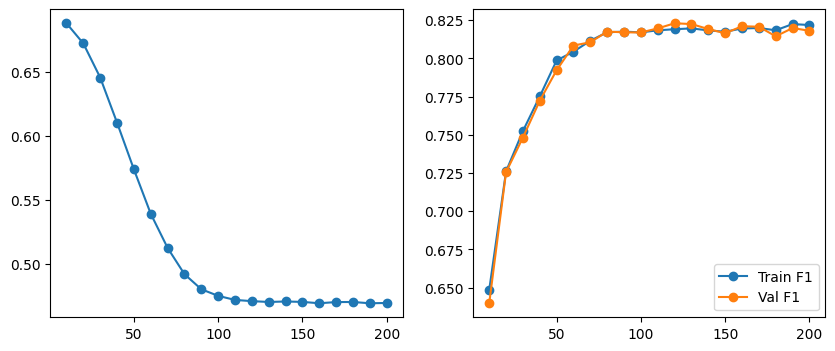


F1-macro: 0.825
ROC-AUC: 0.900


In [ ]:
# Создание большей подвыборки
N_TRAIN_EACH_x = 10000
N_VAL_EACH_x   = 2000
N_TEST_EACH_x  = 2000

sub_train_x = pd.concat([
    df_bin[df_bin['Sentiment']==0].sample(n=N_TRAIN_EACH_x, random_state=1),
    df_bin[df_bin['Sentiment']==1].sample(n=N_TRAIN_EACH_x, random_state=1)
])
sub_val_x = pd.concat([
    df_bin[df_bin['Sentiment']==0].sample(n=N_VAL_EACH_x, random_state=1),
    df_bin[df_bin['Sentiment']==1].sample(n=N_VAL_EACH_x, random_state=1)
])
sub_test_x = pd.concat([
    df_bin[df_bin['Sentiment']==0].sample(n=N_TEST_EACH_x, random_state=1),
    df_bin[df_bin['Sentiment']==1].sample(n=N_TEST_EACH_x, random_state=1)
])

sub_all_x = pd.concat([sub_train_x, sub_val_x, sub_test_x]).reset_index(drop=True)
texts_x = sub_all_x['clean_text'].tolist()
labels_x = sub_all_x['Sentiment'].tolist()

n_docs_x = len(texts_x)
N_TRAIN_x = len(sub_train_x)
N_VAL_x = len(sub_val_x)
N_TEST_x = len(sub_test_x)

print(f"Документов в графе: {n_docs_x}")

# Построение графа
print("Расчёт TF-IDF")
tfidf_gcn_x = TfidfVectorizer(max_features=10000)
tfidf_mat_x = tfidf_gcn_x.fit_transform(texts_x)
vocab_x = tfidf_gcn_x.get_feature_names_out()
n_words_x = len(vocab_x)
word2id_x = {w: i for i, w in enumerate(vocab_x)}

print("Расчёт PMI")
WINDOW = 5
word_freq_x = defaultdict(int)
pair_freq_x = defaultdict(int)
total_windows_x = 0

for text in tqdm(texts_x, desc="PMI анализ"):
    tokens = text.split()
    for i in range(len(tokens)):
        window = tokens[i : i + WINDOW]
        for w in window:
            if w in word2id_x: word_freq_x[w] += 1
        for j in range(len(window)):
            for k in range(j + 1, len(window)):
                if window[j] in word2id_x and window[k] in word2id_x:
                    pair = tuple(sorted([window[j], window[k]]))
                    pair_freq_x[pair] += 1
        total_windows_x += 1

edge_index_x, edge_weight_x = [], []
cx = tfidf_mat_x.tocoo()
for doc_i, word_j, val in zip(cx.row, cx.col, cx.data):
    edge_index_x.append([doc_i, n_docs_x + word_j])
    edge_index_x.append([n_docs_x + word_j, doc_i])
    edge_weight_x.append(val); edge_weight_x.append(val)

for (w1, w2), freq in tqdm(pair_freq_x.items(), desc="Создание рёбер"):
    pmi = np.log((freq / total_windows_x) / (word_freq_x[w1] / total_windows_x) / (word_freq_x[w2] / total_windows_x) + 1e-9)
    if pmi > 0:
        i1, i2 = n_docs_x + word2id_x[w1], n_docs_x + word2id_x[w2]
        edge_index_x.append([i1, i2]); edge_index_x.append([i2, i1])
        edge_weight_x.append(pmi); edge_weight_x.append(pmi)

edge_index_x = torch.tensor(edge_index_x, dtype=torch.long).t().contiguous()
edge_weight_x = torch.tensor(edge_weight_x, dtype=torch.float)

# Признаки узлов
DIM = 200
svd_x = TruncatedSVD(n_components=DIM, random_state=42)
x_x = torch.tensor(np.vstack([svd_x.fit_transform(tfidf_mat_x),
                               svd_x.fit_transform(tfidf_mat_x.T)]), dtype=torch.float)

# Маски и данные
y_x = torch.tensor(labels_x, dtype=torch.long)
train_mask_x = torch.zeros(n_docs_x + n_words_x, dtype=torch.bool)
val_mask_x = torch.zeros(n_docs_x + n_words_x, dtype=torch.bool)
test_mask_x = torch.zeros(n_docs_x + n_words_x, dtype=torch.bool)

train_mask_x[:N_TRAIN_x] = True
val_mask_x[N_TRAIN_x : N_TRAIN_x + N_VAL_x] = True
test_mask_x[N_TRAIN_x + N_VAL_x : n_docs_x] = True

data_x = Data(x=x_x, edge_index=edge_index_x, edge_attr=edge_weight_x, y=y_x,
               train_mask=train_mask_x, val_mask=val_mask_x, test_mask=test_mask_x).to(device)

# Обучение
model_gcn_x = TextGCN(DIM, 128, 2).to(device)
optimizer_x = torch.optim.Adam(model_gcn_x.parameters(), lr=0.01, weight_decay=5e-4)

print("Обучение модели")
start_time_x = time.time()
history_x = {'train_loss': [], 'train_f1': [], 'val_f1': []}

for epoch in tqdm(range(1, 201), desc="GCN Training"):
    model_gcn_x.train()
    optimizer_x.zero_grad()
    out = model_gcn_x(data_x.x, data_x.edge_index, data_x.edge_attr)
    loss = F.cross_entropy(out[data_x.train_mask], data_x.y[data_x.train_mask[:n_docs_x]])
    loss.backward()
    optimizer_x.step()

    if epoch % 10 == 0:
        model_gcn_x.eval()
        with torch.no_grad():
            preds = out[:n_docs_x].argmax(dim=1).cpu().numpy()
            y_true_all = data_x.y.cpu().numpy()
            train_m, val_m = data_mask_x = data_x.train_mask[:n_docs_x].cpu().numpy(), data_x.val_mask[:n_docs_x].cpu().numpy()

            history_x['train_loss'].append(loss.item())
            history_x['train_f1'].append(f1_score(y_true_all[train_m], preds[train_m], average='macro'))
            history_x['val_f1'].append(f1_score(y_true_all[val_m], preds[val_m], average='macro'))

text_gcn_time_x = time.time() - start_time_x
print(f"\nВремя обучения модели: {text_gcn_time_x:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(range(10, 201, 10), history_x['train_loss'], 'o-', label='Loss')
axes[1].plot(range(10, 201, 10), history_x['train_f1'], 'o-', label='Train F1')
axes[1].plot(range(10, 201, 10), history_x['val_f1'], 'o-', label='Val F1')
plt.legend(); plt.show()

model_gcn_x.eval()
with torch.no_grad():
    logits_x = model_gcn_x(data_x.x, data_x.edge_index, data_x.edge_attr)[data_x.test_mask]
    test_preds_x = logits_x.argmax(dim=1).cpu().numpy()
    test_probs_x = F.softmax(logits_x, dim=1)[:, 1].cpu().numpy()
    y_test_true_x = data_x.y[data_x.test_mask[:n_docs_x]].cpu().numpy()

text_gcn_f1_x = f1_score(y_test_true_x, test_preds_x, average='macro')
text_gcn_auc_x = roc_auc_score(y_test_true_x, test_probs_x)

print(f"\nF1-macro: {text_gcn_f1_x:.3f}")
print(f"ROC-AUC: {text_gcn_auc_x:.3f}")

## 3.8 GAT

### На подвыборке

GAT Training: 100%|██████████| 300/300 [00:53<00:00,  5.61it/s, loss=0.5457, tr_f1=0.7994, val_f1=0.8044]


Время обучения GAT: 53.45 сек.
              precision    recall  f1-score   support

    Negative       0.81      0.80      0.80       900
    Positive       0.80      0.81      0.80       900

    accuracy                           0.80      1800
   macro avg       0.80      0.80      0.80      1800
weighted avg       0.80      0.80      0.80      1800

ROC-AUC: 0.88
F1-macro: 0.803


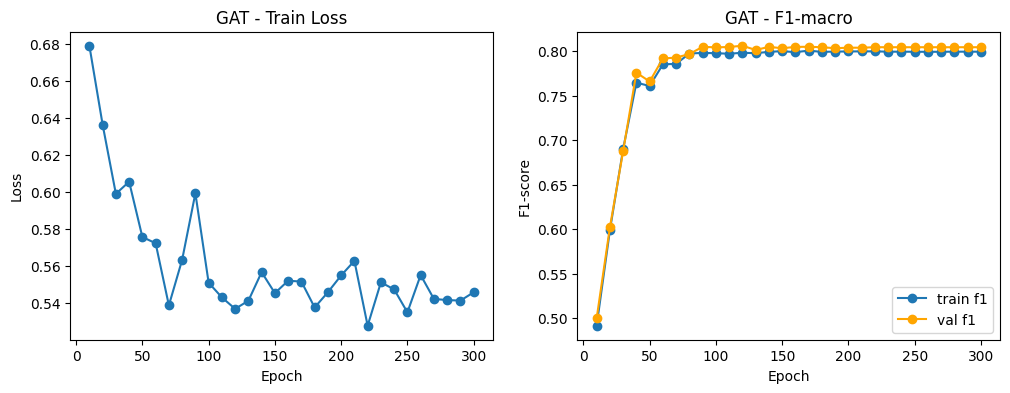

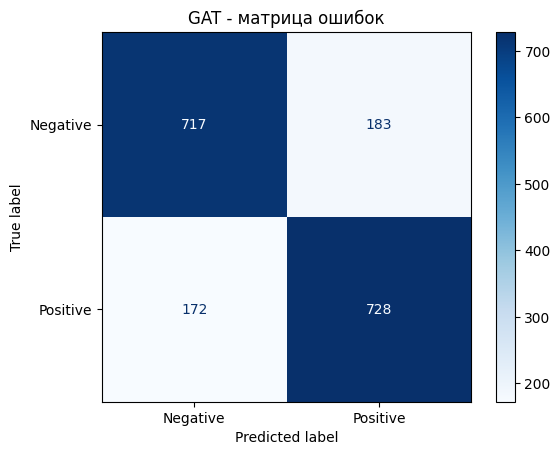

In [ ]:
# Модель GAT
class GATClassifier(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=4, dropout=0.5):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels,
                               heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden_channels * heads, out_channels,
                               heads=1, concat=False, dropout=dropout)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

model_gat = GATClassifier(
    in_channels = DIM,
    hidden_channels = 64,
    out_channels = 2,
    heads = 4,
    dropout = 0.5
).to(device)

optimizer_gat = torch.optim.Adam(model_gat.parameters(), lr=0.005, weight_decay=5e-4)
scheduler_gat = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_gat, mode='min', factor=0.5, patience=10
)

def train_gat():
    model_gat.train()
    optimizer_gat.zero_grad()
    out      = model_gat(data.x, data.edge_index)
    out_docs = out[:n_docs]
    loss     = F.cross_entropy(out_docs[data.train_mask[:n_docs]],
                               data.y[data.train_mask[:n_docs]])
    loss.backward()
    optimizer_gat.step()
    return loss.item()

def eval_gat(mask):
    model_gat.eval()
    with torch.no_grad():
        out      = model_gat(data.x, data.edge_index)
        out_docs = out[:n_docs]
        preds    = out_docs[mask[:n_docs]].argmax(dim=1).cpu().numpy()
        true     = data.y[mask[:n_docs]].cpu().numpy()
    return preds, true

EPOCHS_GAT  = 300
start_gat_time = time.time()
history_gat = {'train_loss': [], 'val_f1': [], 'train_f1': []}

pbar = tqdm(range(1, EPOCHS_GAT + 1), desc="GAT Training")

for epoch in pbar:
    loss = train_gat()
    scheduler_gat.step(loss)

    if epoch % 10 == 0:
        val_preds, val_true = eval_gat(data.val_mask)
        v_f1 = f1_score(val_true, val_preds, average='macro')

        train_preds, train_true = eval_gat(data.train_mask)
        t_f1 = f1_score(train_true, train_preds, average='macro')

        history_gat['train_loss'].append(loss)
        history_gat['val_f1'].append(v_f1)
        history_gat['train_f1'].append(t_f1)

        pbar.set_postfix({
            'loss': f'{loss:.4f}',
            'tr_f1': f'{t_f1:.4f}',
            'val_f1': f'{v_f1:.4f}'
        })

gat_time_sub = time.time() - start_gat_time
print(f"Время обучения GAT: {gat_time_sub:.2f} сек.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(10, EPOCHS_GAT+1, 10), history_gat['train_loss'], 'o-')
axes[0].set_title('GAT - Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(range(10, EPOCHS_GAT+1, 10), history_gat['train_f1'], 'o-', label='train f1')
axes[1].plot(range(10, EPOCHS_GAT+1, 10), history_gat['val_f1'], 'o-', label='val f1', color='orange')
axes[1].set_title('GAT - F1-macro')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1-score')
axes[1].legend()

test_preds, test_true = eval_gat(data.test_mask)
model_gat.eval()
with torch.no_grad():
    out        = model_gat(data.x, data.edge_index)
    test_probs = F.softmax(
        out[:n_docs][data.test_mask[:n_docs]], dim=1
    )[:, 1].cpu().numpy()

gat_f1_sub = f1_score(test_true, test_preds, average='macro')
gat_auc_sub = roc_auc_score(test_true, test_probs)

print(classification_report(test_true, test_preds, target_names=['Negative', 'Positive']))
print("ROC-AUC:", gat_auc_sub.round(3))
print(f"F1-macro: {gat_f1_sub:.3f}")

cm = confusion_matrix(test_true, test_preds)
ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive']).plot(cmap='Blues')
plt.title('GAT - матрица ошибок')
plt.show()

## 3.9 Distilbert

### На подвыборке

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Старт дообучения модели


Эпоха 1 - train f1: 0.869 - val f1: 0.910


Эпоха 2 - train f1: 0.942 - val f1: 0.921


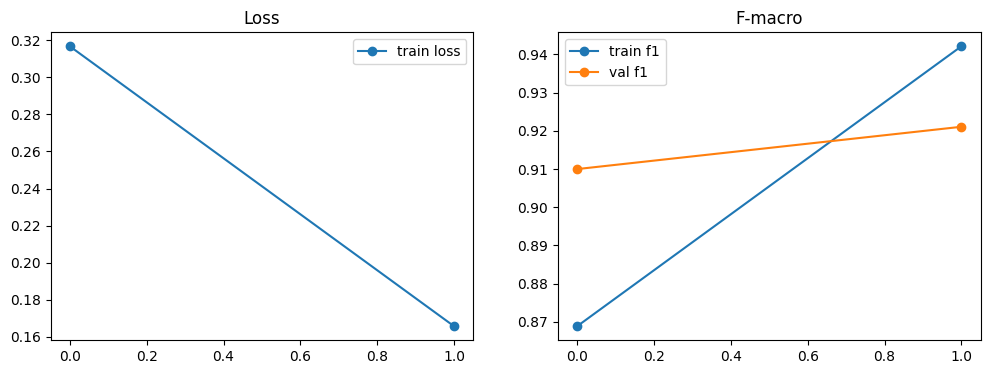

тест: 100%|██████████| 57/57 [00:06<00:00,  8.71it/s]

Время обучения: 194.78 сек.
F-macro: 0.914
ROC-AUC: 0.972
              precision    recall  f1-score   support

           0       0.90      0.93      0.92       900
           1       0.93      0.90      0.91       900

    accuracy                           0.91      1800
   macro avg       0.91      0.91      0.91      1800
weighted avg       0.91      0.91      0.91      1800



In [ ]:
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

class BertDataset(Dataset):
    def __init__(self, df, max_len=128):
        self.texts = df['light_text'].tolist()
        self.labels = df['Sentiment'].tolist()
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            max_length = self.max_len,
            padding = 'max_length',
            truncation = True,
            return_tensors = 'pt'
        )
        return {
            'input_ids': enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_bert_loader = DataLoader(BertDataset(sub_train), batch_size=32, shuffle=True)
val_bert_loader = DataLoader(BertDataset(sub_val), batch_size=32)
test_bert_loader = DataLoader(BertDataset(sub_test), batch_size=32)

# Загрузка модели
model_bert = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels = 2
).to(device)

optimizer_bert = torch.optim.AdamW(model_bert.parameters(), lr=2e-5)

def run_bert_epoch(loader, train=True):
    if train:
        model_bert.train()
    else:
        model_bert.eval()

    total_loss, all_preds, all_labels = 0, [], []

    pbar = tqdm(loader, desc="обучение" if train else "валидация", leave=False)

    with torch.set_grad_enabled(train):
        for batch in pbar:
            ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            targets = batch['label'].to(device)

            outputs = model_bert(input_ids=ids, attention_mask=mask, labels=targets)
            loss = outputs.loss

            if train:
                optimizer_bert.zero_grad()
                loss.backward()
                optimizer_bert.step()

            preds = outputs.logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(targets.cpu().numpy())
            total_loss += loss.item() * targets.size(0)

    avg_f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / len(loader.dataset), avg_f1

print("Старт дообучения модели")
start_bert_time = time.time()
history_bert = {'train_loss': [], 'val_f1': [], 'train_f1': []}

for epoch in range(1, 3):
    t_loss, t_f1 = run_bert_epoch(train_bert_loader, train=True)
    v_loss, v_f1 = run_bert_epoch(val_bert_loader, train=False)

    history_bert['train_loss'].append(t_loss)
    history_bert['train_f1'].append(t_f1)
    history_bert['val_f1'].append(v_f1)

    print(f"Эпоха {epoch} - train f1: {t_f1:.3f} - val f1: {v_f1:.3f}")

bert_time_sub = time.time() - start_bert_time

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history_bert['train_loss'], 'o-', label='train loss')
ax[0].set_title('Loss'); ax[0].legend()
ax[1].plot(history_bert['train_f1'], 'o-', label='train f1')
ax[1].plot(history_bert['val_f1'], 'o-', label='val f1')
ax[1].set_title('F-macro'); ax[1].legend()
plt.show()

model_bert.eval()
test_preds, test_probs, test_true = [], [], []

with torch.no_grad():
    for batch in tqdm(test_bert_loader, desc="тест"):
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        targets = batch['label']

        outputs = model_bert(input_ids=ids, attention_mask=mask)
        probs = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
        preds = outputs.logits.argmax(dim=1).cpu().numpy()

        test_probs.extend(probs)
        test_preds.extend(preds)
        test_true.extend(targets.numpy())

bert_f1_sub = f1_score(test_true, test_preds, average='macro')
bert_auc_sub = roc_auc_score(test_true, test_probs)

print(f"\nВремя обучения: {bert_time_sub:.2f} сек.")
print(f"F-macro: {bert_f1_sub:.3f}")
print(f"ROC-AUC: {bert_auc_sub:.3f}")
print(classification_report(test_true, test_preds))

# 4. Итоги

In [ ]:
full_results = pd.DataFrame([
    {'Модель': 'VADER', 'Тип': 'Unsupervised', 'F1-macro': 0.720, 'ROC-AUC': 0.688, 'Время (сек)': 65.0},
    {'Модель': 'TextRank + VADER', 'Тип': 'Unsupervised', 'F1-macro': 0.610, 'ROC-AUC': 0.596, 'Время (сек)': 163.0},
    {'Модель': 'TF-IDF + LogReg', 'Тип': 'Supervised', 'F1-macro': 0.875, 'ROC-AUC': 0.975, 'Время (сек)': 5.25},
    {'Модель': 'TF-IDF + SVM', 'Тип': 'Supervised', 'F1-macro': 0.9, 'ROC-AUC': 0.976, 'Время (сек)': 69.0},
    {'Модель': 'TF-IDF + LogReg (Оптимизир.)', 'Тип': 'Supervised', 'F1-macro': 0.8752, 'ROC-AUC': 0.9756, 'Время (сек)': 14.08},
    {'Модель': 'LSTM', 'Тип': 'Supervised', 'F1-macro': 0.916, 'ROC-AUC': 0.986, 'Время (сек)': 714.0},
])

print("Таблица результатов на полной выборке:")
display(full_results.sort_values('F1-macro', ascending=False))

Таблица результатов на полной выборке:


,Модель,Тип,F1-macro,ROC-AUC,Время (сек)
5,LSTM,Supervised,0.9160,0.9860,714.00
3,TF-IDF + SVM,Supervised,0.9000,0.9760,69.00
4,TF-IDF + LogReg (Оптимизир.),Supervised,0.8752,0.9756,14.08
2,TF-IDF + LogReg,Supervised,0.8750,0.9750,5.25
0,VADER,Unsupervised,0.7200,0.6880,65.00
1,TextRank + VADER,Unsupervised,0.6100,0.5960,163.00


In [ ]:
sub_results = pd.DataFrame([
    {'Модель': 'VADER', 'Тип': 'Unsupervised', 'F1-macro': 0.638, 'ROC-AUC': 0.668, 'Время (сек)': 2.2},
    {'Модель': 'TextRank', 'Тип': 'Unsupervised', 'F1-macro': 0.549, 'ROC-AUC': 0.598, 'Время (сек)': 9.2},
    {'Модель': 'TF-IDF + LogReg', 'Тип': 'Supervised', 'F1-macro': 0.86, 'ROC-AUC': 0.940, 'Время (сек)': 0.5},
    {'Модель': 'TF-IDF + SVM', 'Тип': 'Supervised', 'F1-macro': 0.86, 'ROC-AUC': 0.94, 'Время (сек)': 1.02},
    {'Модель': 'LSTM', 'Тип': 'Supervised', 'F1-macro': 0.766, 'ROC-AUC': 0.852, 'Время (сек)': 14.3},
    {'Модель': 'DistilBERT', 'Тип': 'Supervised', 'F1-macro': 0.914, 'ROC-AUC': 0.972, 'Время (сек)': 194.0},
    {'Модель': 'TextGCN', 'Тип': 'Graph', 'F1-macro': 0.828, 'ROC-AUC': 0.909, 'Время (сек)': 10.8},
    {'Модель': 'GAT', 'Тип': 'Graph', 'F1-macro': 0.803, 'ROC-AUC': 0.88, 'Время (сек)': 53.5},
    {'Модель': 'EdgeSAGE', 'Тип': 'Graph', 'F1-macro': 0.5, 'ROC-AUC': 0.513, 'Время (сек)': 2.7},
])

print("Таблица результатов на подвыборке:")
display(sub_results.sort_values('F1-macro', ascending=False))

Таблица результатов на подвыборке:


,Модель,Тип,F1-macro,ROC-AUC,Время (сек)
5,DistilBERT,Supervised,0.914,0.972,194.00
3,TF-IDF + SVM,Supervised,0.860,0.940,1.02
2,TF-IDF + LogReg,Supervised,0.860,0.940,0.50
6,TextGCN,Graph,0.828,0.909,10.80
7,GAT,Graph,0.803,0.880,53.50
4,LSTM,Supervised,0.766,0.852,14.30
0,VADER,Unsupervised,0.638,0.668,2.20
1,TextRank,Unsupervised,0.549,0.598,9.20
8,EdgeSAGE,Graph,0.500,0.513,2.70


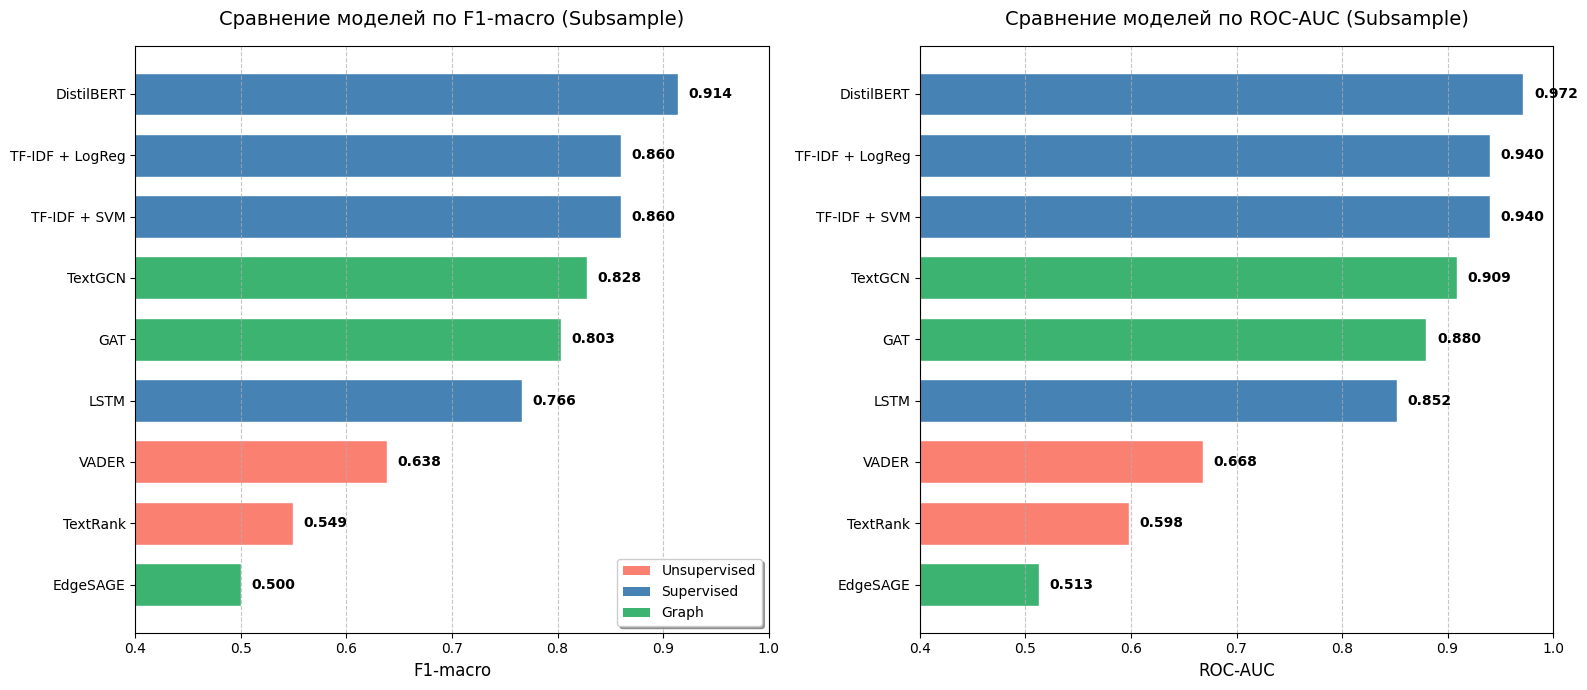

In [ ]:
def plot_comparison(results_df, title_suffix):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    colors = {'Unsupervised': 'salmon', 'Supervised': 'steelblue', 'Graph': 'mediumseagreen'}

    for ax, metric in zip(axes, ['F1-macro', 'ROC-AUC']):
        sorted_df = results_df.sort_values(metric)

        bars = ax.barh(
            sorted_df['Модель'],
            sorted_df[metric],
            color=[colors[t] for t in sorted_df['Тип']],
            edgecolor='white',
            height=0.7
        )

        ax.set_xlabel(metric, fontsize=12)
        ax.set_title(f'Сравнение моделей по {metric} ({title_suffix})', fontsize=14, pad=15)
        ax.set_xlim(0.4, 1.0)
        ax.grid(axis='x', linestyle='--', alpha=0.7)

        for bar, val in zip(bars, sorted_df[metric]):
            ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                    f'{val:.3f}', va='center', fontsize=10, fontweight='bold')

    legend_elements = [Patch(facecolor=c, label=t) for t, c in colors.items()]
    axes[0].legend(handles=legend_elements, loc='lower right', frameon=True, shadow=True)

    plt.tight_layout()
    plt.show()

plot_comparison(sub_results, "Subsample")

**Выводы:**  
1. Методы с учителем (Supervised) оказались лучше методов без учителя (Unsupervised). Лидерsы (DistilBERT, LSTM, LogReg, SVM) достигают метрики F1-macro > 0.85, а лучшие методы без учителя дают результат 0.6 – 0.7. Получается, наличие размеченных данных важно для анализа тональности, так как лексические словари не всегда способны уловить контекстуальные зависимости и специфику предметной области.

2. Модели TF-IDF + LogReg/SVM обучаются быстро и выдают результат, сопоставимый с нейросетями. Автоматический подбор гиперпараметров (Grid Search) позволил дополнительно стабилизировать метрики, сделав эту модель оптимальным выбором для работы.

3. TextGCN и GAT показали хорошие (~0.8) результаты. Это доказывает, что представление текста в виде семантической сети слов и документов может быть эффективно для выделения тональности. EdgeSAGE (F1=0.500) показала самый низкий результат, потому что структурная информация (кто кого оценивал) без учета семантики текста недостаточна для определения эмоционального окраса отзыва. У графовых моделей (TextGCN/GAT) есть высокий потенциал роста при наличии больших объемов видеопамяти (VRAM), позволяющих построить граф на всех узлах. В таком случае эти модели могут превзойти остальные варианты.

4. DistilBERT очень хорошо справляется с контекстом и пониманием скрытых смыслов, но очень быстро переобучается. У него также большой потенциал. LSTM показала отличный результат на полном датасете (F1=0.916), но потребовала значительного времени на обучение (более 11 минут).
